# Small-lesion PGA-UNet comparison at 128, 256, and 512

This notebook evaluates PGA-UNet at three input resolutions on the same GT-area-defined small-lesion image stems for FracAtlas. It reports `center_zoom` and `center_shift` separately, merges predictions and GT masks at image level, and summarizes native plus normalized HD95.

The fixed training seed is `22120196`. This notebook does not retrain models.

In [1]:
# ═════ SETUP — clone repo + download dataset (Kaggle / Colab) ═════
import os, sys
os.system('pip install -q gdown tqdm opencv-python timm scipy matplotlib')
import gdown

BASE = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
os.chdir(BASE)
REPO = 'https://github.com/ThongLuc2k3/PGA_Unet2D.git'
REPO_ROOT = f'{BASE}/PGA_Unet2D'
PGA_ROOT  = f'{REPO_ROOT}/Source/Prompt-Guided-XRay-Segmentation'
if not os.path.exists(REPO_ROOT):
    os.system(f'git clone -q --branch main --single-branch {REPO} {REPO_ROOT}')

DATASET_NAME = 'dataset_FracAtlas'
DATASET_ID   = '1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv'
DS_ZIP  = f'{BASE}/{DATASET_NAME}.zip'
DS_PATH = f'{PGA_ROOT}/{DATASET_NAME}'
if not os.path.exists(DS_PATH):
    if not os.path.exists(DS_ZIP):
        gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}', DS_ZIP, quiet=False)
    os.system(f'unzip -oq {DS_ZIP} -d {PGA_ROOT}/')

os.chdir(REPO_ROOT)
print(f'✅ Setup complete | base={BASE} | dataset={DATASET_NAME}')


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=786cc359-4ffe-4e7f-a017-62e33ce51edb
To: /kaggle/working/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:03<00:00, 70.6MB/s] 


✅ Setup complete | base=/kaggle/working | dataset=dataset_FracAtlas


In [2]:
import csv
import math
import os
import sys
from collections import OrderedDict
from pathlib import Path

import cv2
import numpy as np
import torch
from scipy.ndimage import binary_erosion, distance_transform_edt
from torch.utils.data import DataLoader
from tqdm import tqdm

TRAINING_SEED = 22120196
RESOLUTIONS = (128, 256, 512)
PROMPT_MODES = ("center_zoom", "center_shift")
SMALL_LESION_COUNT = 50
SCALE_FACTOR = 3.0
SHIFT_RATIO = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CWD = Path.cwd().resolve()
if (CWD / "Source" / "Prompt-Guided-XRay-Segmentation").exists():
    PROJECT_ROOT = CWD
elif (CWD / "PGA_Unet2D" / "Source" / "Prompt-Guided-XRay-Segmentation").exists():
    PROJECT_ROOT = CWD / "PGA_Unet2D"
else:
    raise FileNotFoundError("Run this notebook inside the PGA_Unet2D workspace or a cloned Colab copy.")

PKG_ROOT = PROJECT_ROOT / "Source" / "Prompt-Guided-XRay-Segmentation"
DATASET_ROOT = PKG_ROOT / os.environ.get("PROMPT_DATASET_ROOT", "dataset_FracAtlas")
CHECKPOINT_SPECS = {
    128: ("pga_unet_center_mixed_x3_shift05_qhead_128_best.pth", "1y0dcbnRzELEJ79yx7xDXEjAxIwT9XC3I"),
    256: ("pga_unet_center_mixed_x3_shift05_qhead_256_best.pth", "1U9CNawER4ckiFBUGpb_K1CoDxhtU5kWG"),
    512: ("pga_unet_center_mixed_x3_shift05_qhead_512_best.pth", "1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU"),
}
CHECKPOINT_DIR = PKG_ROOT / "checkpoints"
RESULTS_DIR = PKG_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Fetch any checkpoint that is not present yet.
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
import gdown as _gdown
for _res, (_fn, _cid) in CHECKPOINT_SPECS.items():
    _dst = CHECKPOINT_DIR / _fn
    if not _dst.exists():
        _gdown.download(f'https://drive.google.com/uc?id={_cid}', str(_dst), quiet=False)
    assert _dst.exists(), f'missing checkpoint for {_res}: {_fn}'

if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

print(f"project={PROJECT_ROOT}")
print(f"dataset={DATASET_ROOT.name} | seed={TRAINING_SEED} | device={DEVICE}")

Downloading...
From: https://drive.google.com/uc?id=1y0dcbnRzELEJ79yx7xDXEjAxIwT9XC3I
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_128_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 17.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1U9CNawER4ckiFBUGpb_K1CoDxhtU5kWG
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_256_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 59.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ZUyhKEKqCZmPyGDBBOpsfQ7BuqJGFBhU
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_512_best.pth
100%|██████████| 11.9M/11.9M [00:01<00:00, 11.7MB/s]


project=/kaggle/working/PGA_Unet2D
dataset=dataset_FracAtlas | seed=22120196 | device=cuda


In [3]:
def calc_hd95(pred_mask, gt_mask, img_size):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    if not pred_mask.any() and not gt_mask.any():
        return 0.0
    if not pred_mask.any() or not gt_mask.any():
        return float(img_size)
    pred_edge = pred_mask ^ binary_erosion(pred_mask)
    gt_edge = gt_mask ^ binary_erosion(gt_mask)
    d1 = distance_transform_edt(~gt_edge)[pred_edge]
    d2 = distance_transform_edt(~pred_edge)[gt_edge]
    if not len(d1) or not len(d2):
        return float(img_size)
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_metrics_img(prob_map, gt_map, img_size):
    pred_mask = (prob_map > 0.5).astype(np.float32)
    gt_mask = (gt_map > 0.5).astype(np.float32)
    eps = 1e-6
    tp = float((pred_mask * gt_mask).sum())
    fp = float((pred_mask * (1.0 - gt_mask)).sum())
    fn = float(((1.0 - pred_mask) * gt_mask).sum())
    hd95 = calc_hd95(pred_mask, gt_mask, img_size)
    if gt_mask.sum() == 0 or pred_mask.sum() == 0:
        cbl = 0.0
    else:
        ys, xs = np.where(gt_mask > 0.5)
        yp, xp = np.where(pred_mask > 0.5)
        diag = math.sqrt((ys.max() - ys.min()) ** 2 + (xs.max() - xs.min()) ** 2) + eps
        cbl = float(np.clip(1.0 - math.sqrt((xp.mean() - xs.mean()) ** 2 + (yp.mean() - ys.mean()) ** 2) / diag, 0.0, 1.0))
    return {
        "dice": float((2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)),
        "iou": float((tp + eps) / (tp + fp + fn + eps)),
        "precision": float(tp / (tp + fp + eps)),
        "recall": float((tp + eps) / (tp + fn + eps)),
        "hd95": hd95,
        "hd95_normalized": float(hd95 / (math.sqrt(2.0) * img_size)),
        "cbl": cbl,
    }

def summarize(records):
    keys = ["dice", "iou", "precision", "recall", "hd95", "hd95_normalized", "cbl"]
    summary = {}
    for key in keys:
        values = np.array([record["metrics"][key] for record in records], dtype=np.float64)
        summary[key] = float(values.mean())
        summary[f"{key}_std"] = float(values.std(ddof=0))
    summary["n_images"] = len(records)
    return summary

def checkpoint_path(img_size):
    filename, checkpoint_id = CHECKPOINT_SPECS[img_size]
    path = CHECKPOINT_DIR / filename
    if path.exists():
        return path
    raise FileNotFoundError(
        f"Missing checkpoint for {img_size}: {path}. Replace {checkpoint_id} with a real checkpoint before running."
    )

def collect_small_lesion_stems():
    image_dir = DATASET_ROOT / "test" / "images"
    json_dir = DATASET_ROOT / "test" / "annotations"
    ds = PromptSegmentationDataset(str(image_dir), str(json_dir), img_size=512, is_train=False, prompt_mode="center_zoom", scale_factor=SCALE_FACTOR, shift_ratio=SHIFT_RATIO)
    groups = OrderedDict()
    for idx, (img_name, _) in enumerate(ds.all_samples):
        groups.setdefault(img_name, np.zeros((512, 512), dtype=np.float32))
        _, mask_t, _ = ds[idx]
        np.maximum(groups[img_name], mask_t[0].numpy(), out=groups[img_name])
    ranked = sorted(groups, key=lambda name: float(groups[name].sum()))
    return [Path(name).stem for name in ranked[:SMALL_LESION_COUNT]]

def collect_small_lesion_balanced(n_multi=5, n_single=5):
    """10 stems in the SAME order as test-subcat-small-r256's small_lesion_balanced_test_stems."""
    image_dir = DATASET_ROOT / "test" / "images"
    json_dir = DATASET_ROOT / "test" / "annotations"
    ds = PromptSegmentationDataset(str(image_dir), str(json_dir), img_size=512, is_train=False, prompt_mode="center_zoom", scale_factor=SCALE_FACTOR, shift_ratio=SHIFT_RATIO)
    area = OrderedDict(); count = {}
    for idx, (img_name, _) in enumerate(ds.all_samples):
        count[img_name] = count.get(img_name, 0) + 1
        area.setdefault(img_name, np.zeros((512, 512), dtype=np.float32))
        _, mask_t, _ = ds[idx]
        np.maximum(area[img_name], mask_t[0].numpy(), out=area[img_name])
    ranked = sorted(area, key=lambda n: float(area[n].sum()))[:SMALL_LESION_COUNT]
    multi  = [Path(n).stem for n in ranked if count[n] >= 2]
    single = [Path(n).stem for n in ranked if count[n] == 1]
    chosen = multi[:n_multi] + single[:n_single]
    chosen += [Path(n).stem for n in ranked if Path(n).stem not in chosen][:(n_multi + n_single) - len(chosen)]
    return chosen

_F4_KEEP = set()   # stems for which evaluate_resolution keeps img/prompt/prob/gt arrays

def evaluate_resolution(img_size, prompt_mode, selected_stems):
    image_dir = DATASET_ROOT / "test" / "images"
    json_dir = DATASET_ROOT / "test" / "annotations"
    ds = PromptSegmentationDataset(str(image_dir), str(json_dir), img_size=img_size, is_train=False, prompt_mode=prompt_mode, scale_factor=SCALE_FACTOR, shift_ratio=SHIFT_RATIO)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)
    model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True, use_quality_head=True).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path(img_size), map_location=DEVICE, weights_only=True))
    model.eval()
    groups = OrderedDict()
    selected_stems = set(selected_stems)
    with torch.no_grad():
        for idx, (image_t, mask_t, prompt_t) in enumerate(tqdm(loader, desc=f"R{img_size} {prompt_mode}")):
            img_name, _ = ds.all_samples[idx]
            stem = Path(img_name).stem
            if stem not in selected_stems:
                continue
            if img_name not in groups:
                groups[img_name] = {
                    "img_name": img_name,
                    "n_samples": 0,
                    "gt": np.zeros((img_size, img_size), dtype=np.float32),
                    "prob": np.zeros((img_size, img_size), dtype=np.float32),
                }
                if stem in _F4_KEEP:
                    groups[img_name]["img"] = image_t[0, 0].cpu().numpy()
                    groups[img_name]["prompt"] = np.zeros((img_size, img_size), dtype=np.float32)
            logits = model(image_t.to(DEVICE), prompt_t.to(DEVICE))
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
            gt = mask_t[0, 0].cpu().numpy()
            groups[img_name]["n_samples"] += 1
            np.maximum(groups[img_name]["gt"], gt, out=groups[img_name]["gt"])
            np.maximum(groups[img_name]["prob"], prob, out=groups[img_name]["prob"])
            if stem in _F4_KEEP:
                np.maximum(groups[img_name]["prompt"], prompt_t[0, 0].cpu().numpy(), out=groups[img_name]["prompt"])
    records = []
    for img_name, payload in groups.items():
        stem = Path(img_name).stem
        metrics = calc_metrics_img(payload["prob"], payload["gt"], img_size)
        rec = {
            "img_name": img_name,
            "stem": stem,
            "n_samples": payload["n_samples"],
            "metrics": metrics,
        }
        if "img" in payload:
            rec["img"] = payload["img"]; rec["prompt"] = payload["prompt"]
            rec["prob"] = payload["prob"]; rec["gt"] = payload["gt"]
        records.append(rec)
    records.sort(key=lambda record: record["stem"])
    return records


In [4]:
small_stems = collect_small_lesion_stems()
VIZ_STEMS = collect_small_lesion_balanced()
_F4_KEEP.clear(); _F4_KEEP.update(VIZ_STEMS)
print(f"Selected {len(small_stems)} stems from the smallest GT-union lesion areas.")
print(f"Figure rows (same order as test-subcat-small-r256): {VIZ_STEMS}")

all_records = {}
summaries = []
for img_size in RESOLUTIONS:
    for prompt_mode in PROMPT_MODES:
        records = evaluate_resolution(img_size, prompt_mode, small_stems)
        key = (img_size, prompt_mode)
        all_records[key] = records
        summary = summarize(records)
        summary.update({"resolution": img_size, "prompt_mode": prompt_mode})
        summaries.append(summary)

metric_keys = ["dice", "iou", "precision", "recall", "hd95", "hd95_normalized", "cbl"]
print("\n" + "=" * 122)
print("SMALL-LESION PGA COMPARISON AT 128 / 256 / 512")
print("=" * 122)
print(f"{'Resolution':<12}{'Prompt':<14}{'N':>4}" + "".join(f"{name:>12}" for name in ["Dice", "IoU", "Prec", "Recall", "HD95", "HD95n", "CBL"]))
for summary in summaries:
    print(f"{summary['resolution']:<12}{summary['prompt_mode']:<14}{summary['n_images']:>4}" + "".join(f"{summary[key]:>12.4f}" for key in metric_keys))

summary_path = RESULTS_DIR / "subcat_pga_small_r128_256_512_fracatlas_summary.csv"
with summary_path.open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["resolution", "prompt_mode", "n_images"] + metric_keys + [f"{key}_std" for key in metric_keys])
    for summary in summaries:
        writer.writerow([summary["resolution"], summary["prompt_mode"], summary["n_images"]] + [summary[key] for key in metric_keys] + [summary[f"{key}_std"] for key in metric_keys])

paired_path = RESULTS_DIR / "subcat_pga_small_r128_256_512_fracatlas_paired.csv"
with paired_path.open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["stem", "prompt_mode", "resolution", "n_samples"] + metric_keys)
    for (img_size, prompt_mode), records in all_records.items():
        for record in records:
            writer.writerow([record["stem"], prompt_mode, img_size, record["n_samples"]] + [record["metrics"][key] for key in metric_keys])

degradation_path = RESULTS_DIR / "subcat_pga_small_r128_256_512_fracatlas_degradation_vs_512.csv"
with degradation_path.open("w", newline="") as handle:
    writer = csv.writer(handle)
    writer.writerow(["prompt_mode", "resolution", "metric", "mean_delta_vs_512"])
    for prompt_mode in PROMPT_MODES:
        ref = {record["stem"]: record for record in all_records[(512, prompt_mode)]}
        for img_size in (128, 256):
            cur = {record["stem"]: record for record in all_records[(img_size, prompt_mode)]}
            common = sorted(set(ref) & set(cur))
            for metric in metric_keys:
                deltas = [cur[stem]["metrics"][metric] - ref[stem]["metrics"][metric] for stem in common]
                writer.writerow([prompt_mode, img_size, metric, float(np.mean(deltas))])

print(f"\nSaved summary CSV: {summary_path}")
print(f"Saved paired CSV: {paired_path}")
print(f"Saved degradation CSV: {degradation_path}")

Selected 50 stems from the smallest GT-union lesion areas.
Figure rows (same order as test-subcat-small-r256): ['IMG0003395', 'IMG0002745', 'IMG0002568', 'IMG0002300', 'IMG0002484', 'IMG0002376', 'IMG0003713', 'IMG0003810', 'IMG0003952', 'IMG0002594']


R512 center_shift: 100%|██████████| 92/92 [00:03<00:00, 25.93it/s]



SMALL-LESION PGA COMPARISON AT 128 / 256 / 512
Resolution  Prompt           N        Dice         IoU        Prec      Recall        HD95       HD95n         CBL
128         center_zoom     50      0.6085      0.4615      0.5221      0.8315      8.8698      0.0490      0.8275
128         center_shift    50      0.5426      0.3933      0.4449      0.7613     10.5798      0.0584      0.7568
256         center_zoom     50      0.6415      0.4840      0.5095      0.9159     10.3155      0.0285      0.8873
256         center_shift    50      0.6100      0.4507      0.4998      0.8454     10.8326      0.0299      0.8448
512         center_zoom     50      0.7202      0.5776      0.6421      0.8700      8.3480      0.0115      0.9065
512         center_shift    50      0.7117      0.5697      0.6452      0.8373      8.2022      0.0113      0.8925

Saved summary CSV: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/results/subcat_pga_small_r128_256_512_fracatlas_summary.csv
S

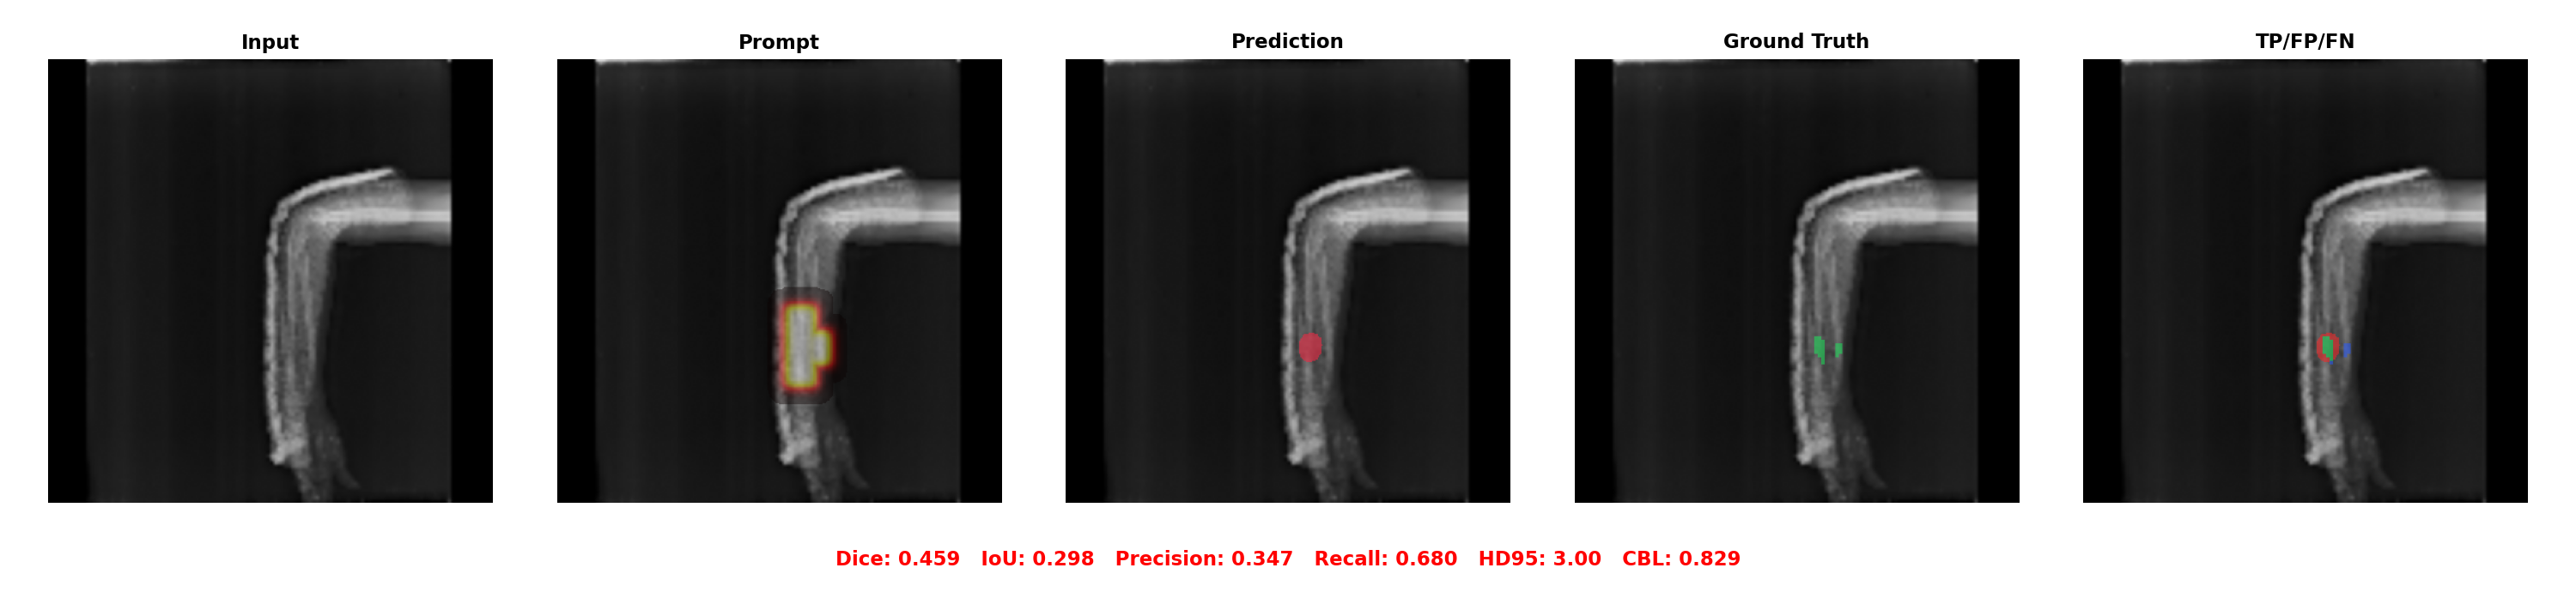

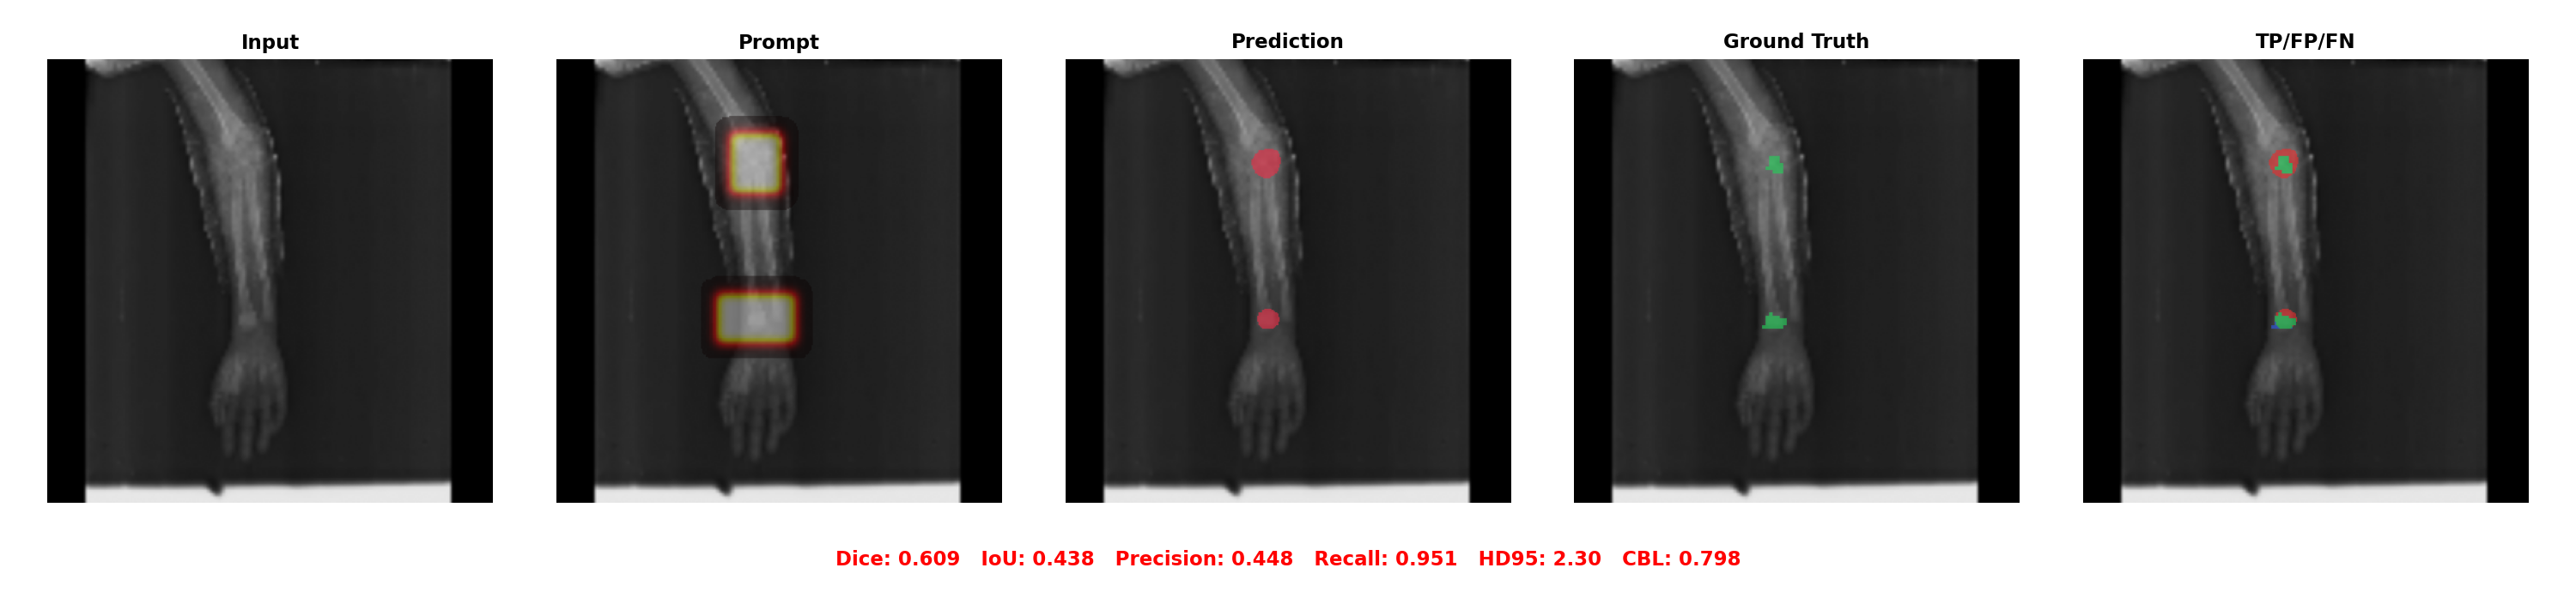

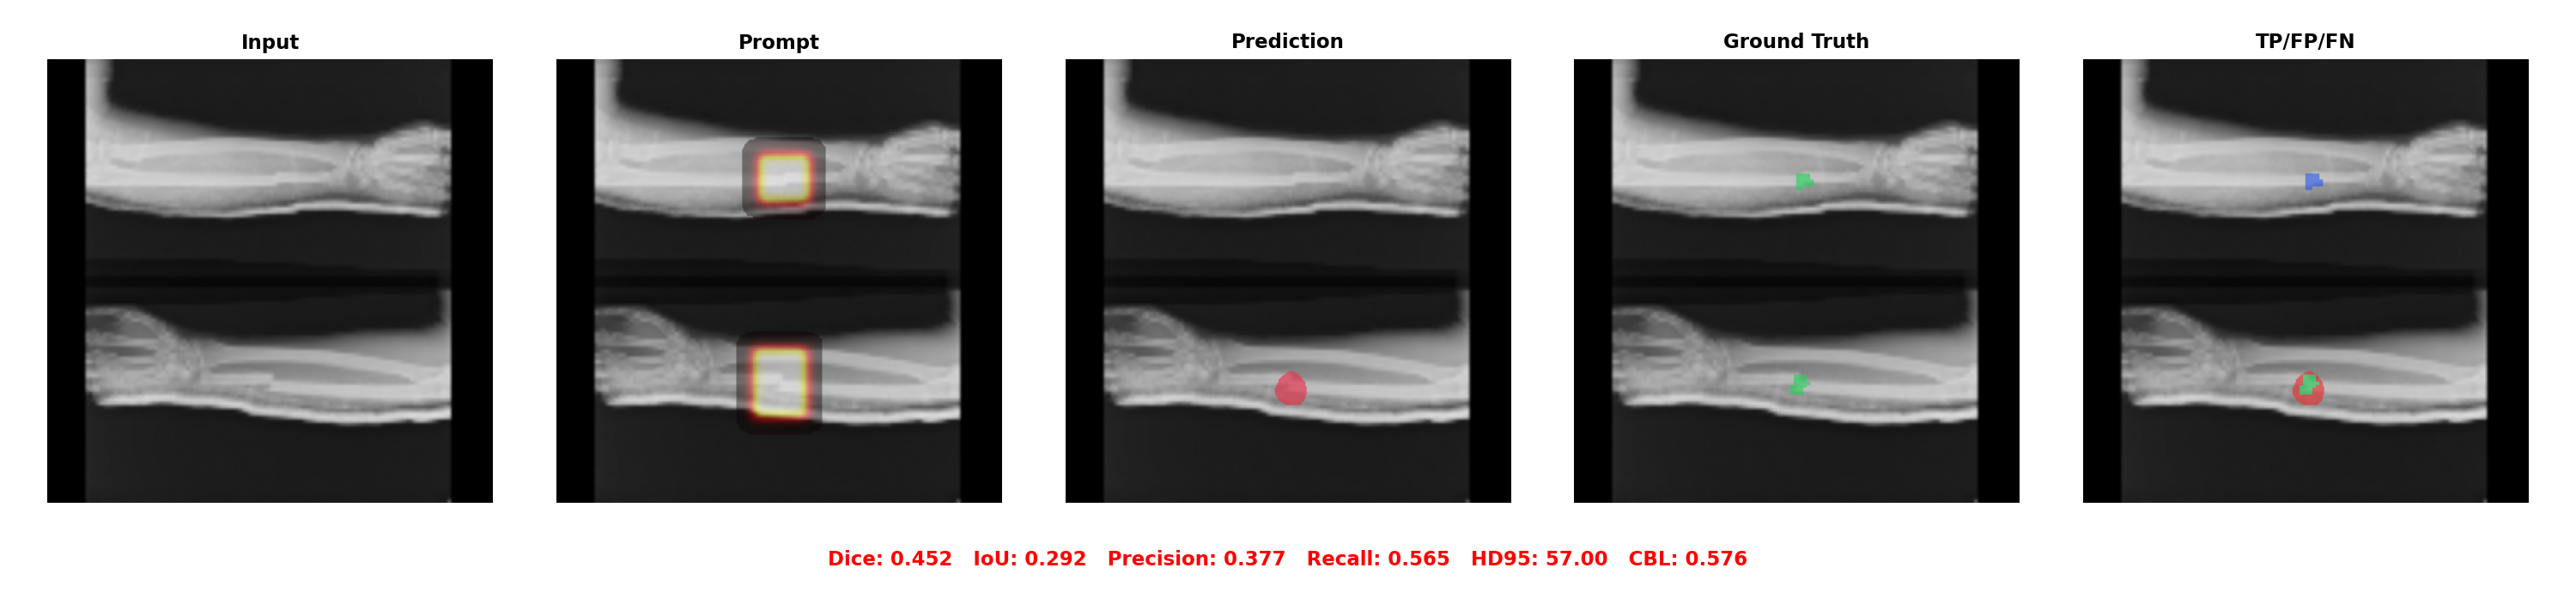

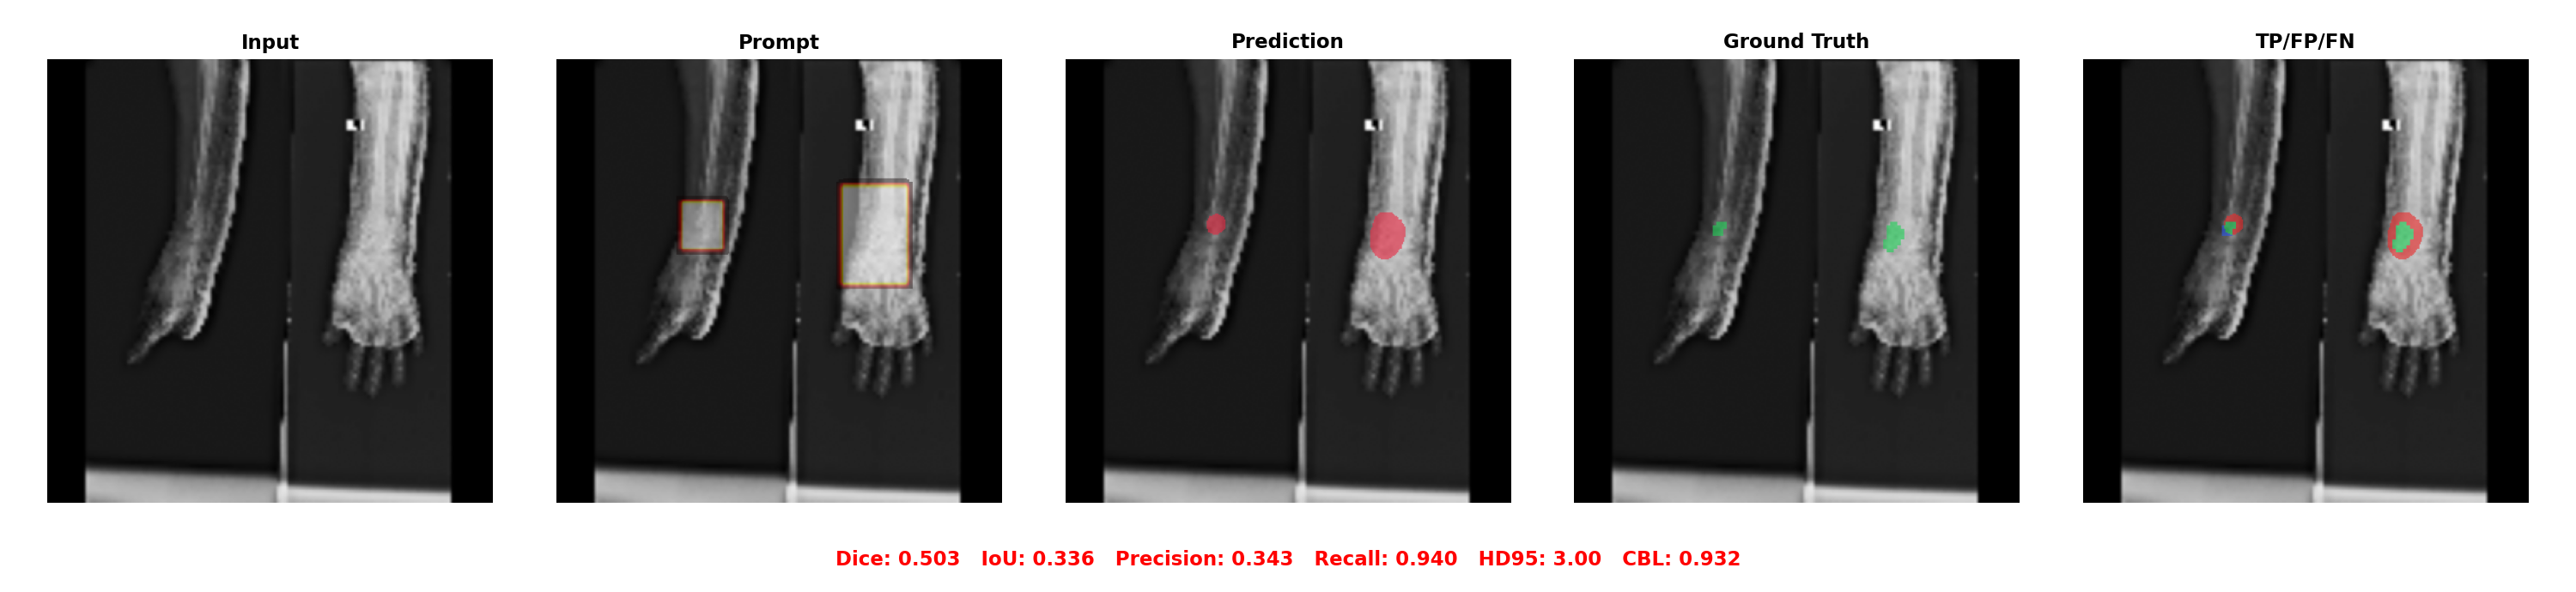

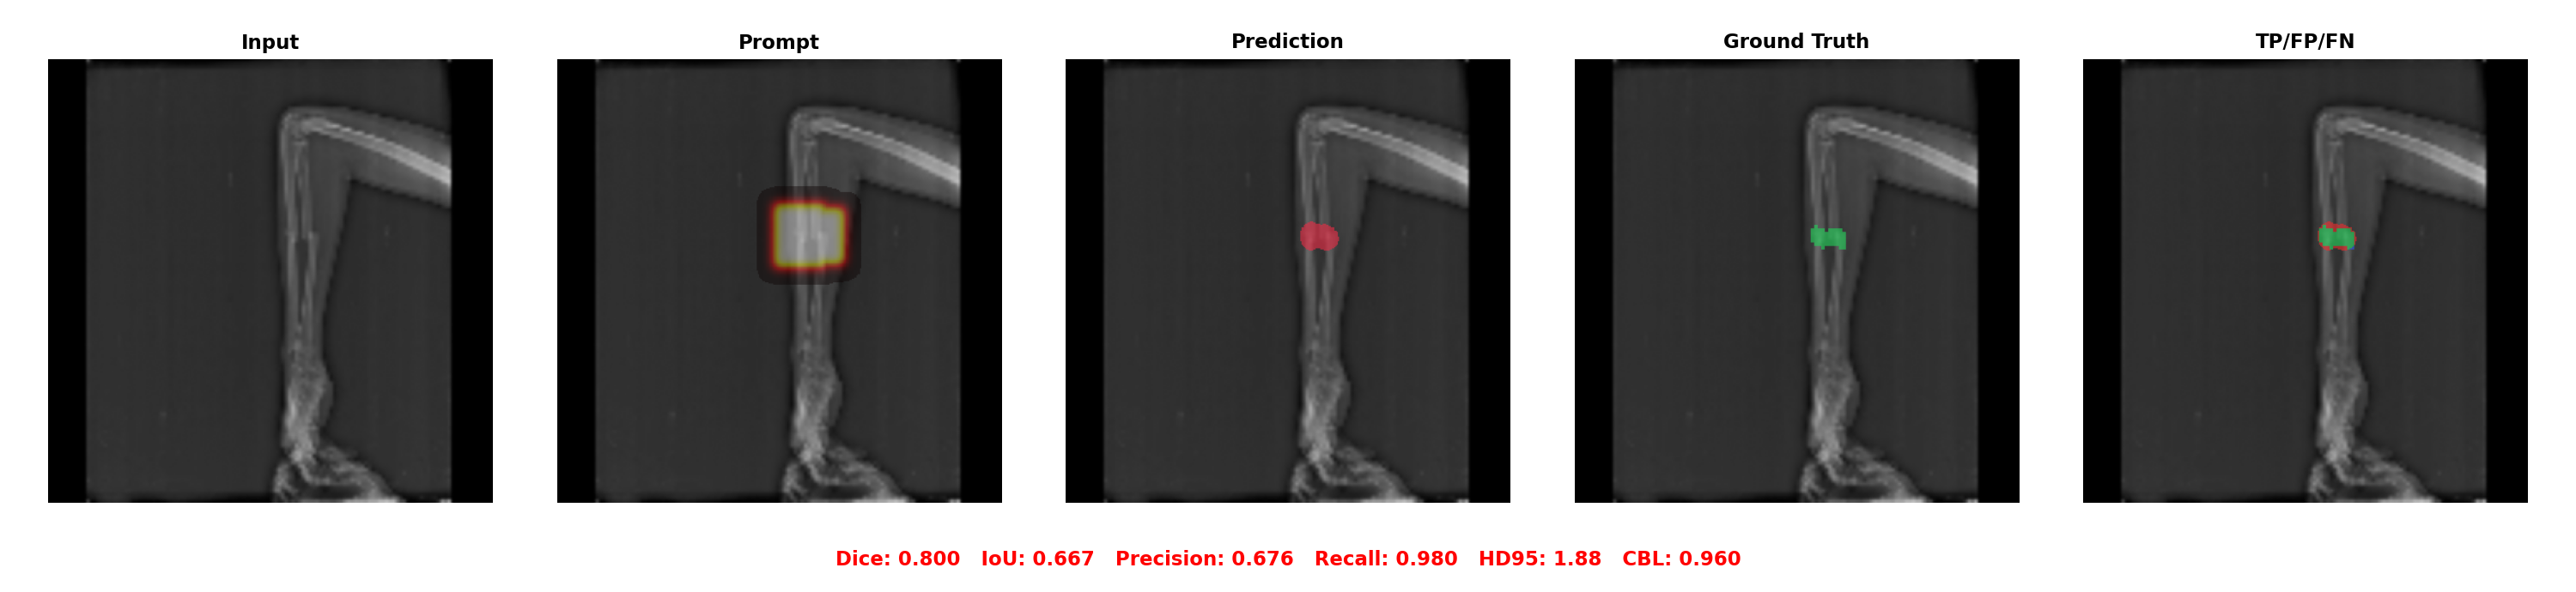

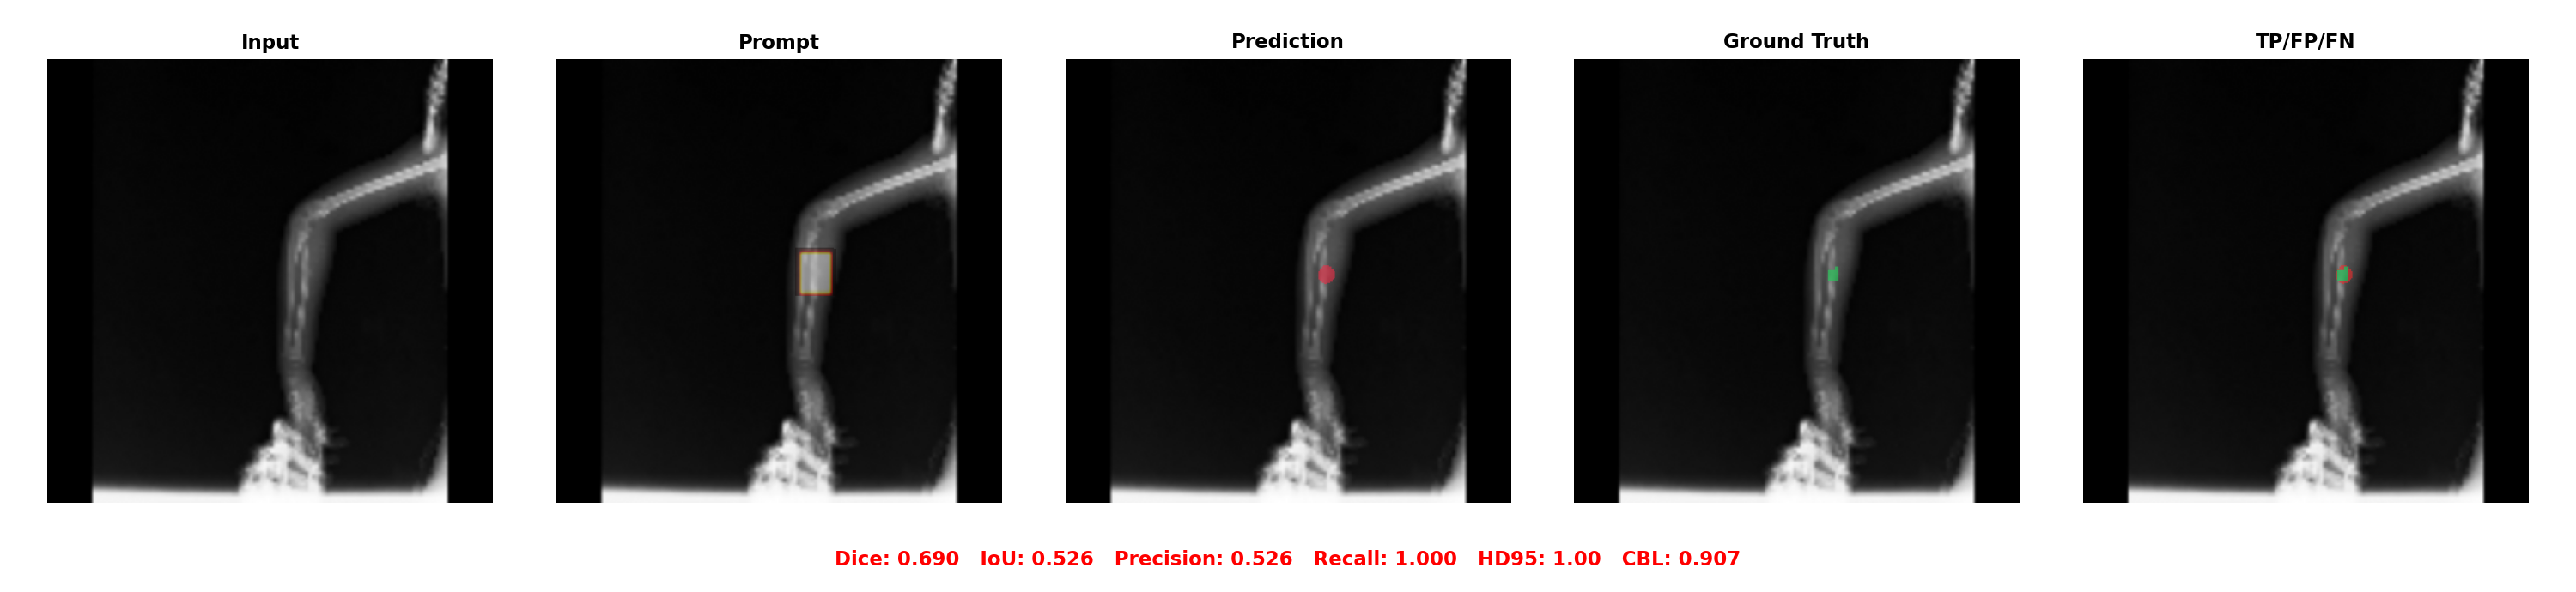

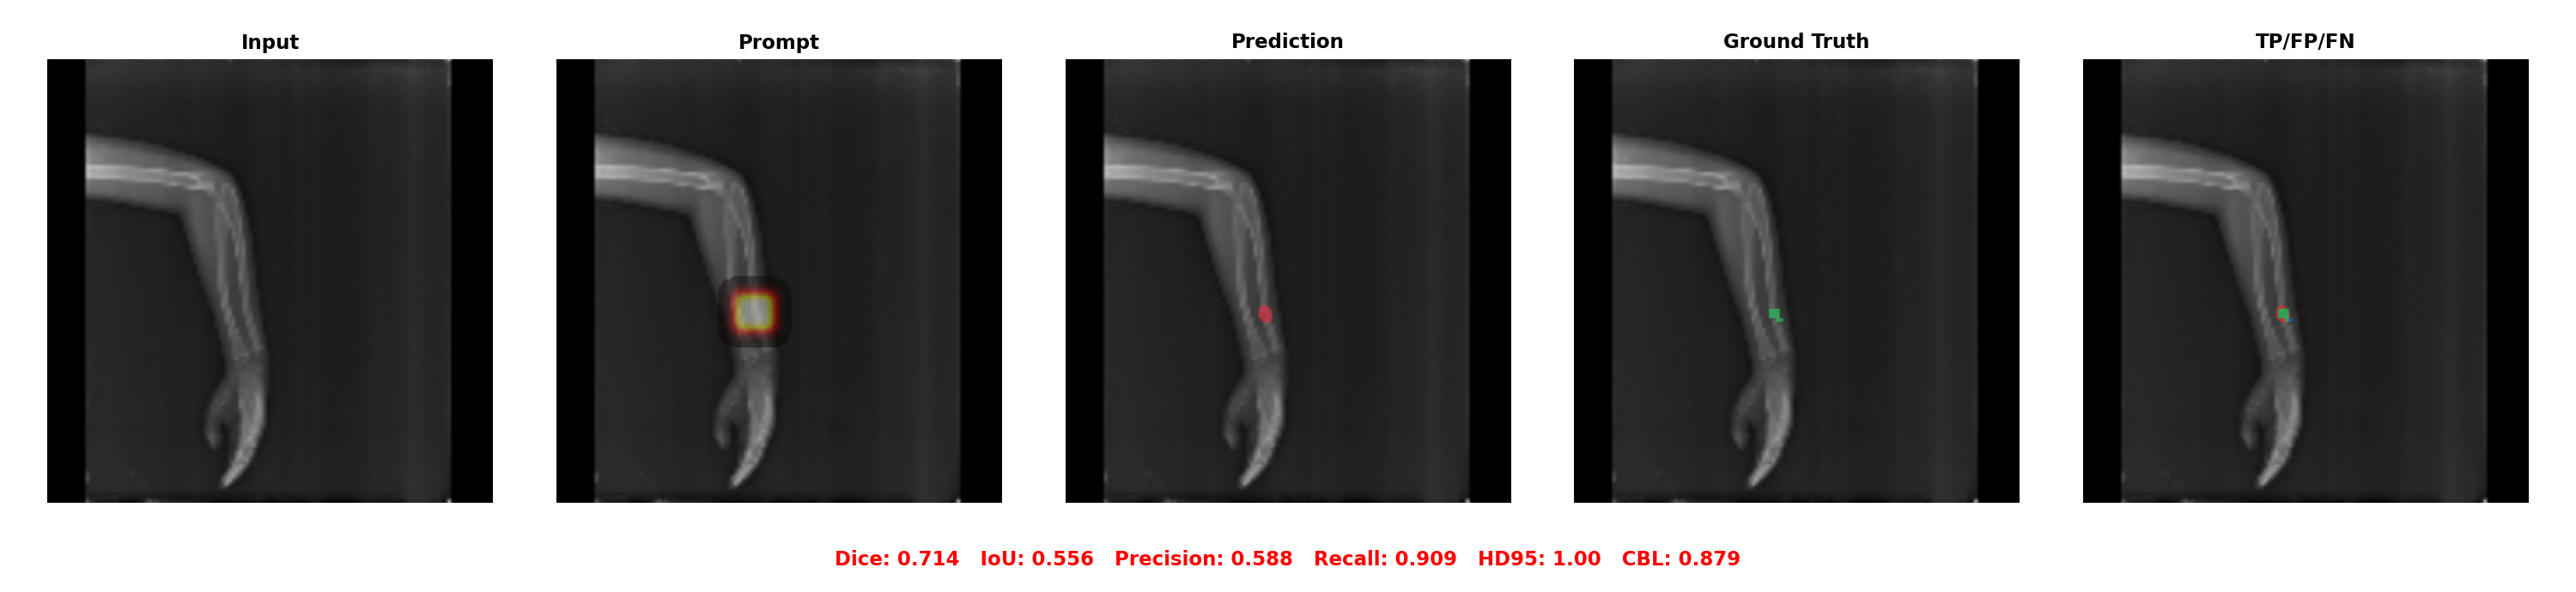

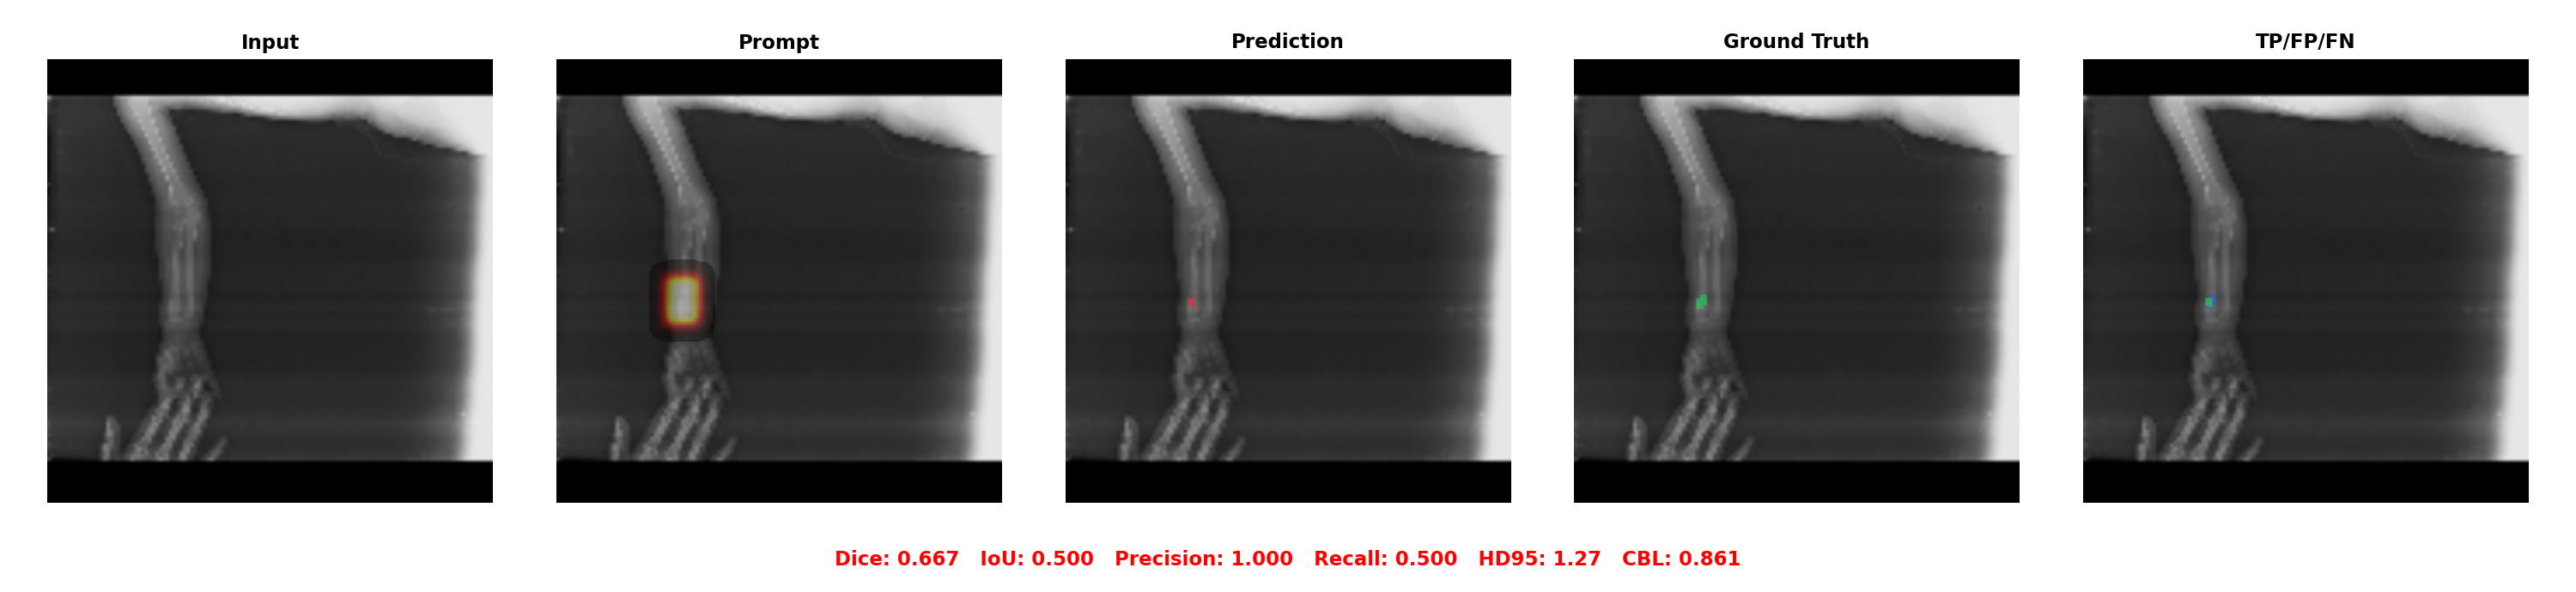

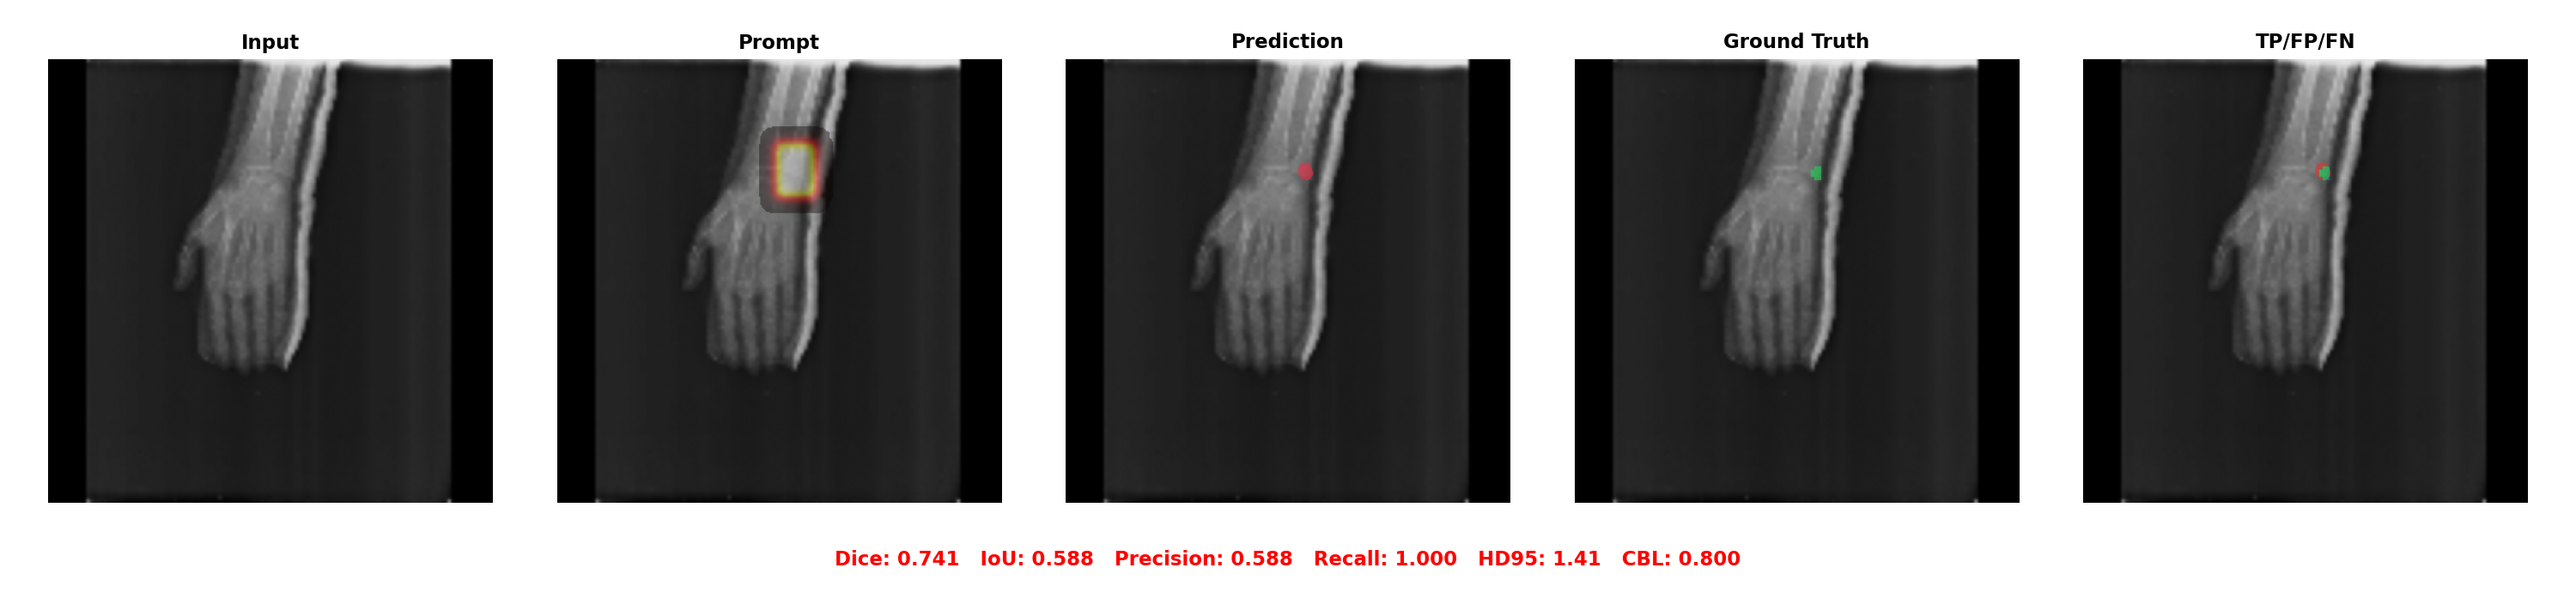

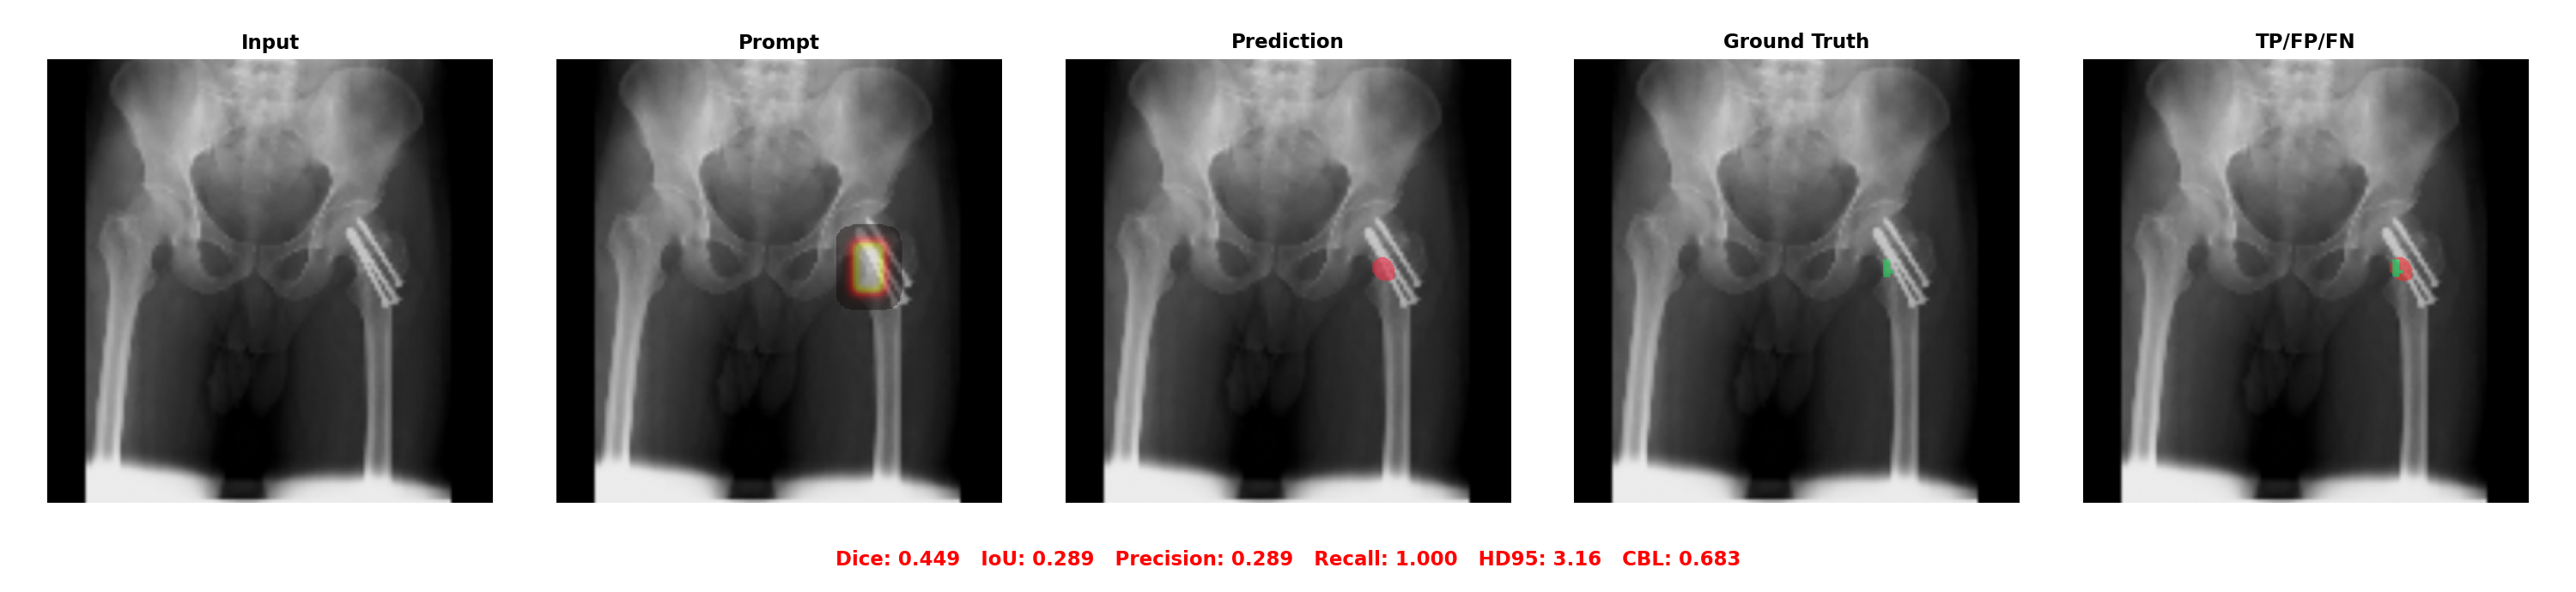

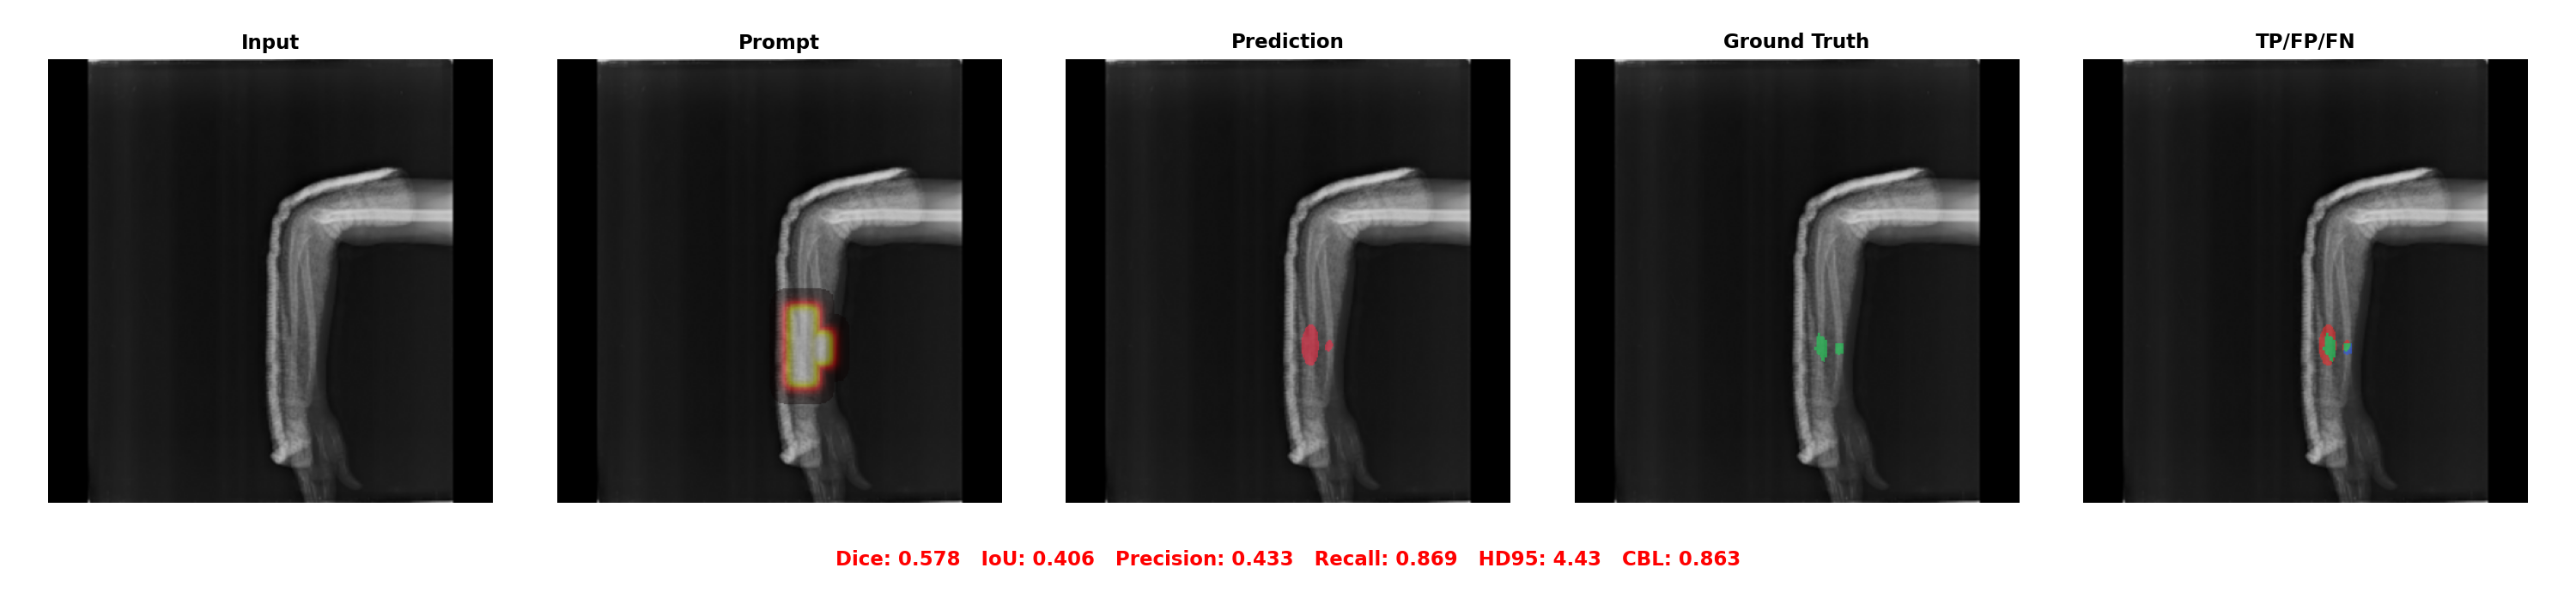

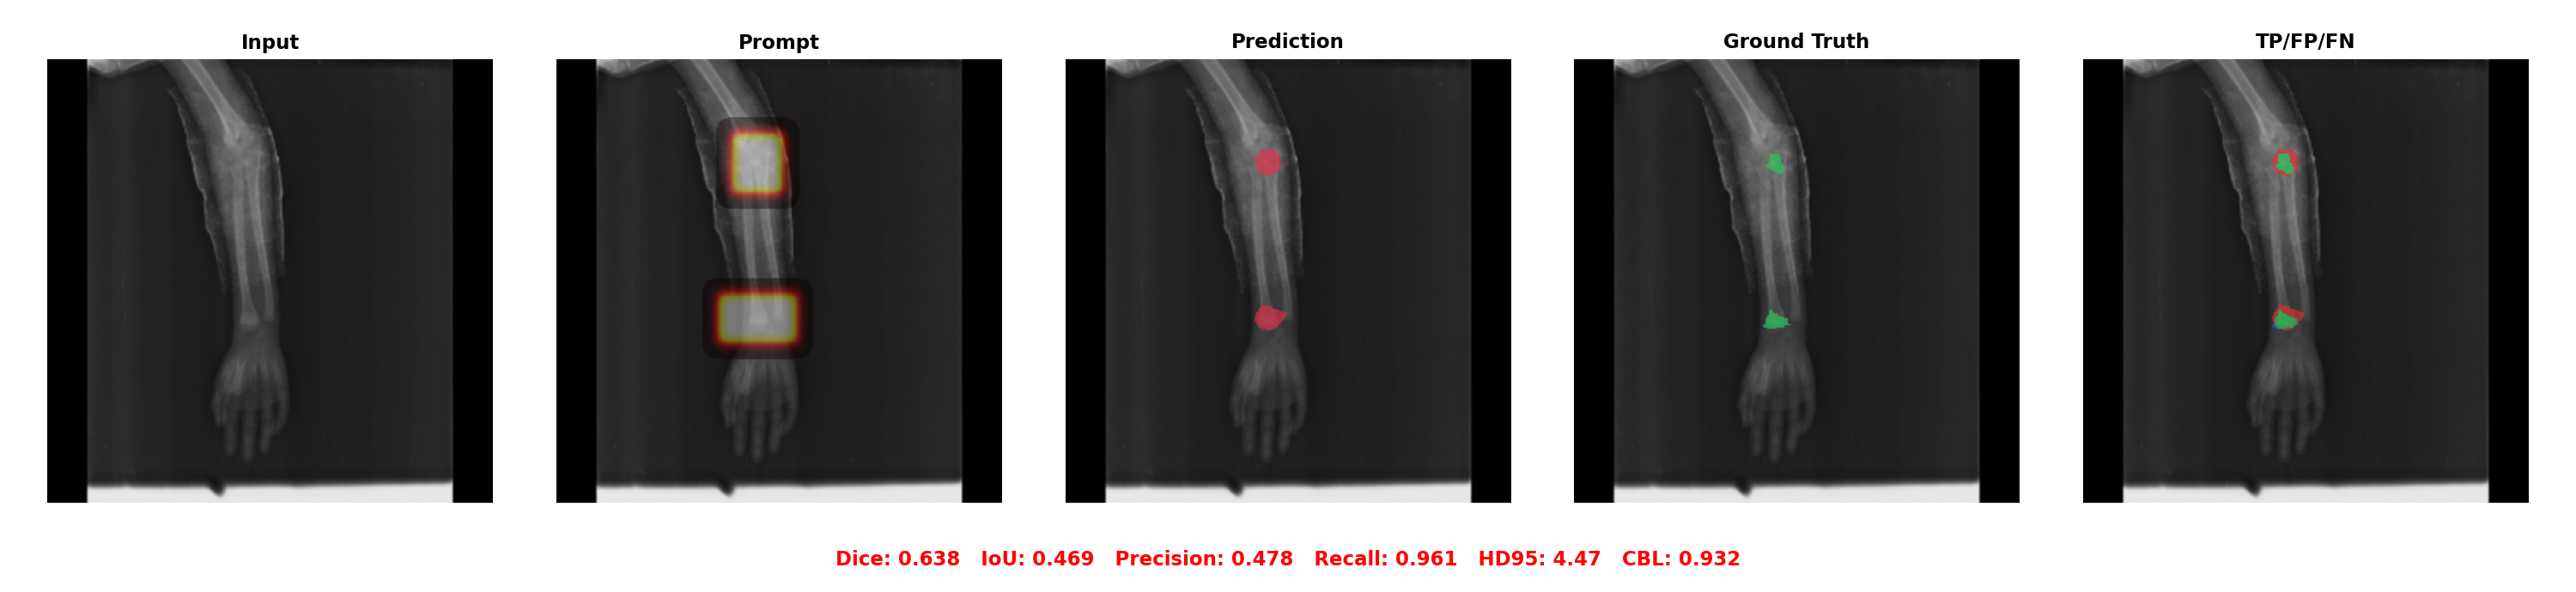

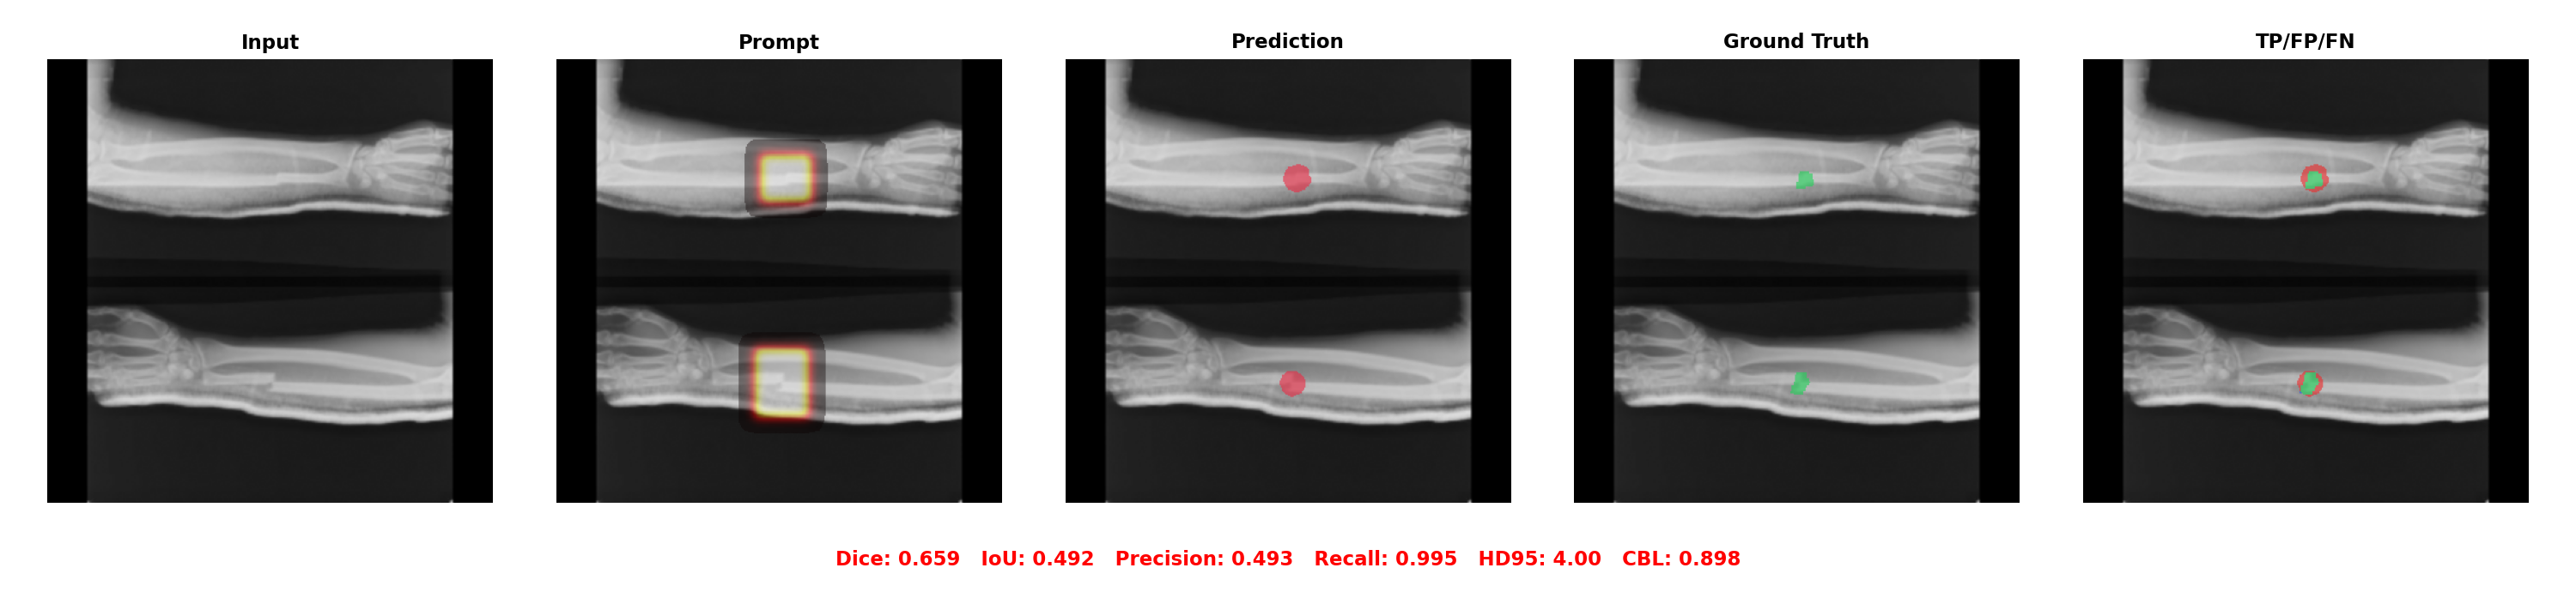

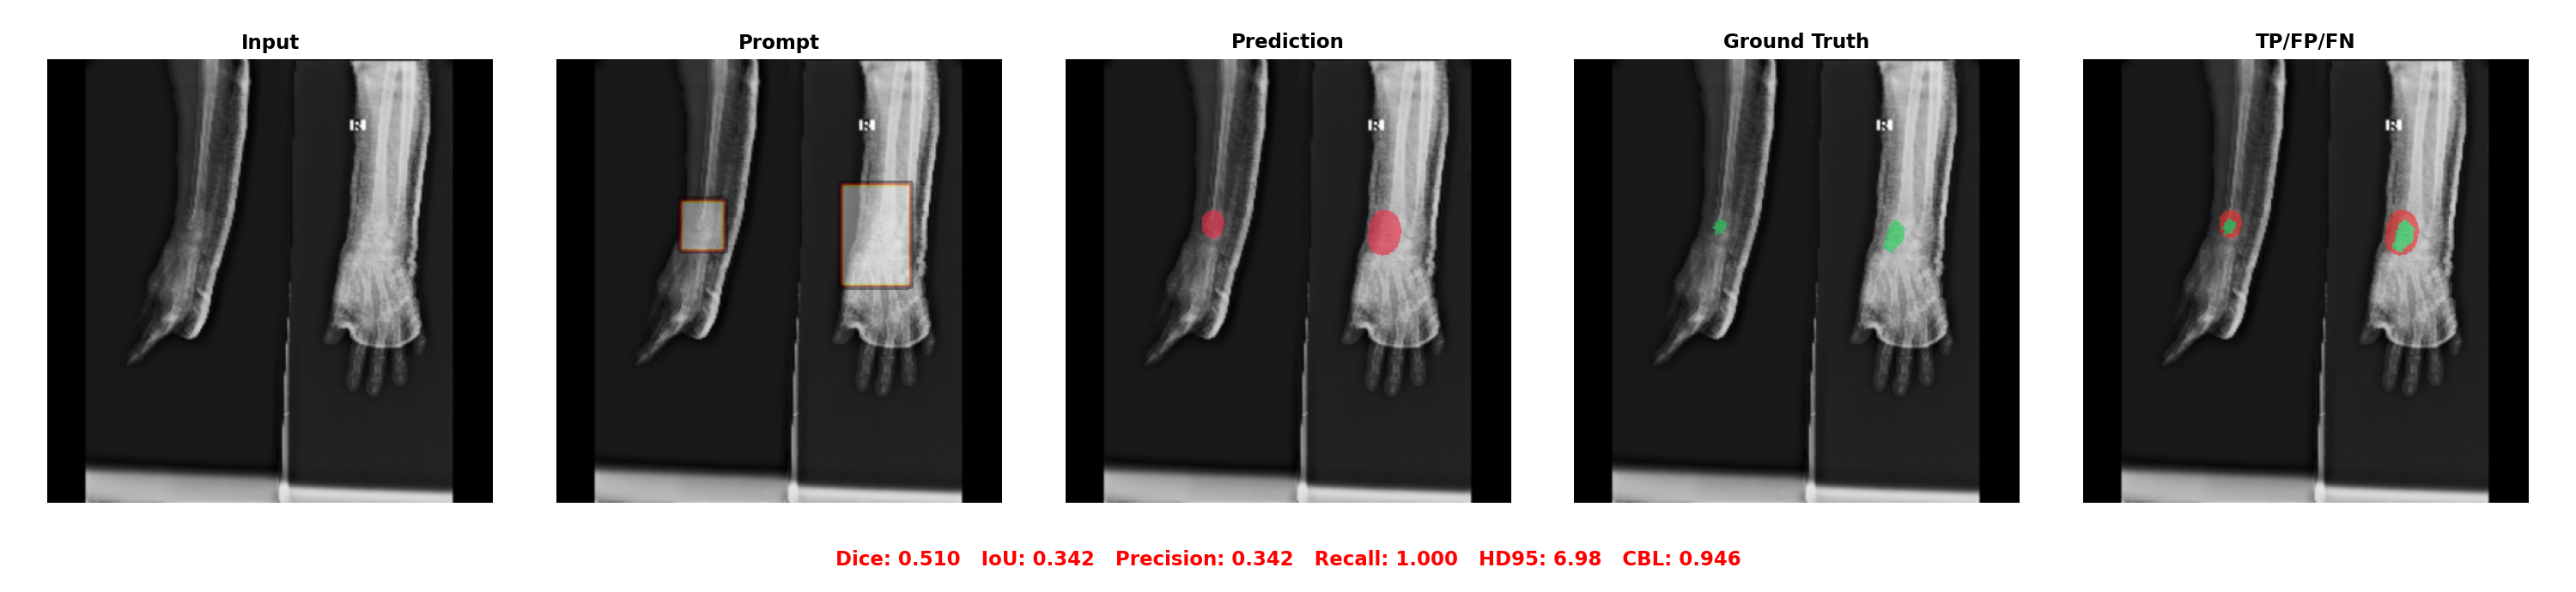

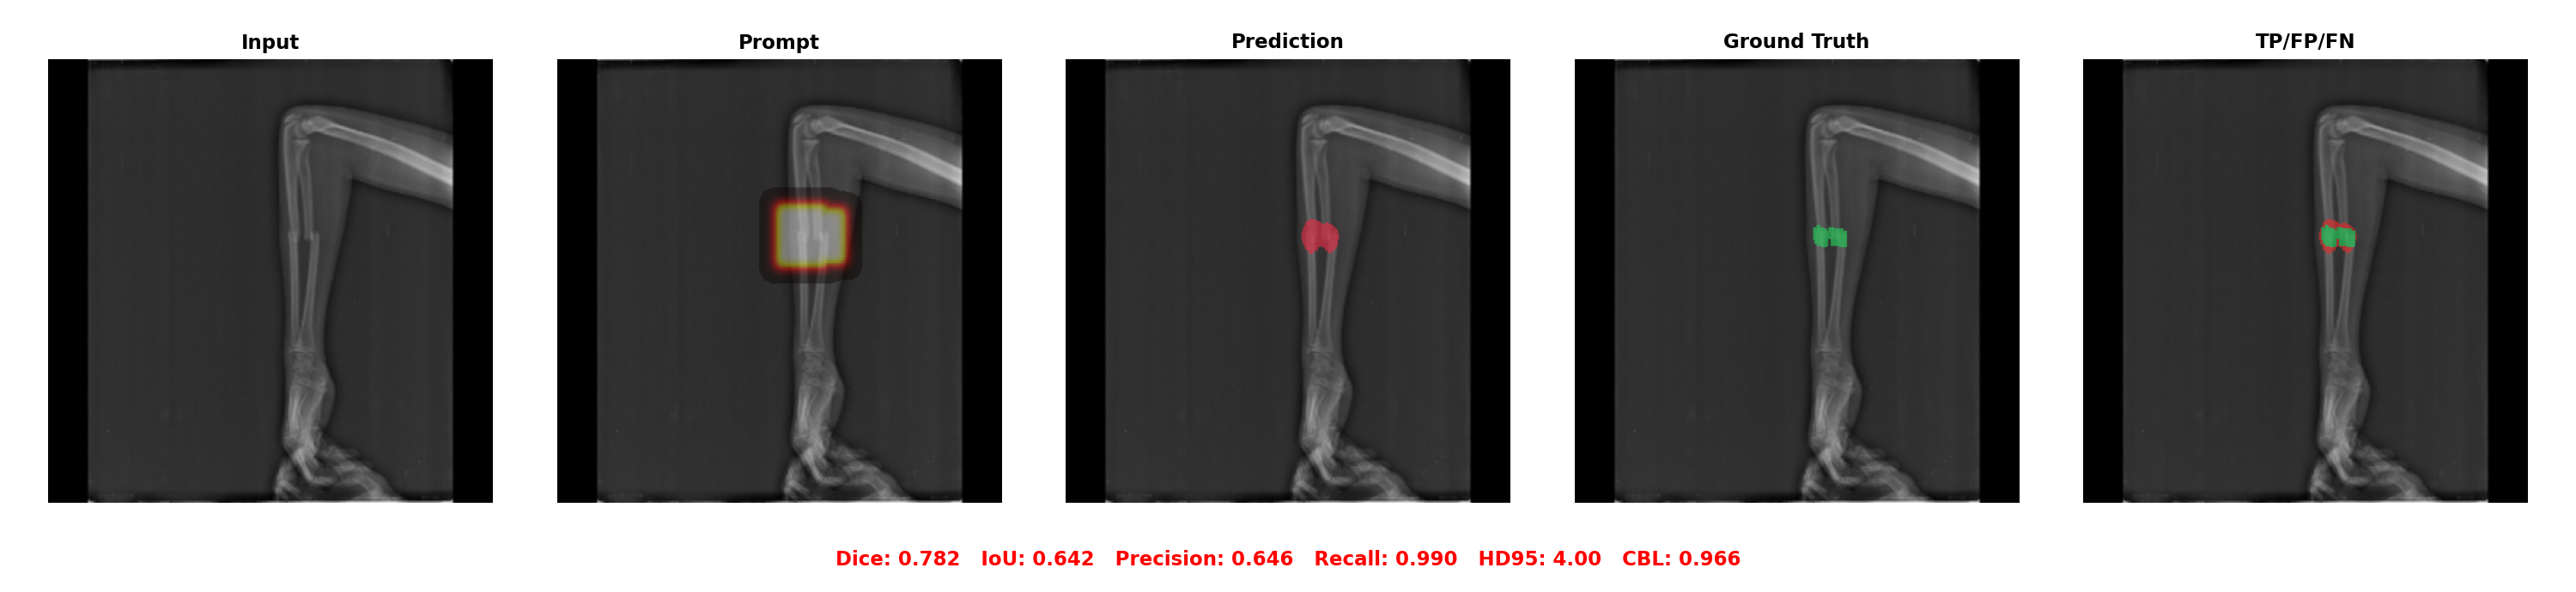

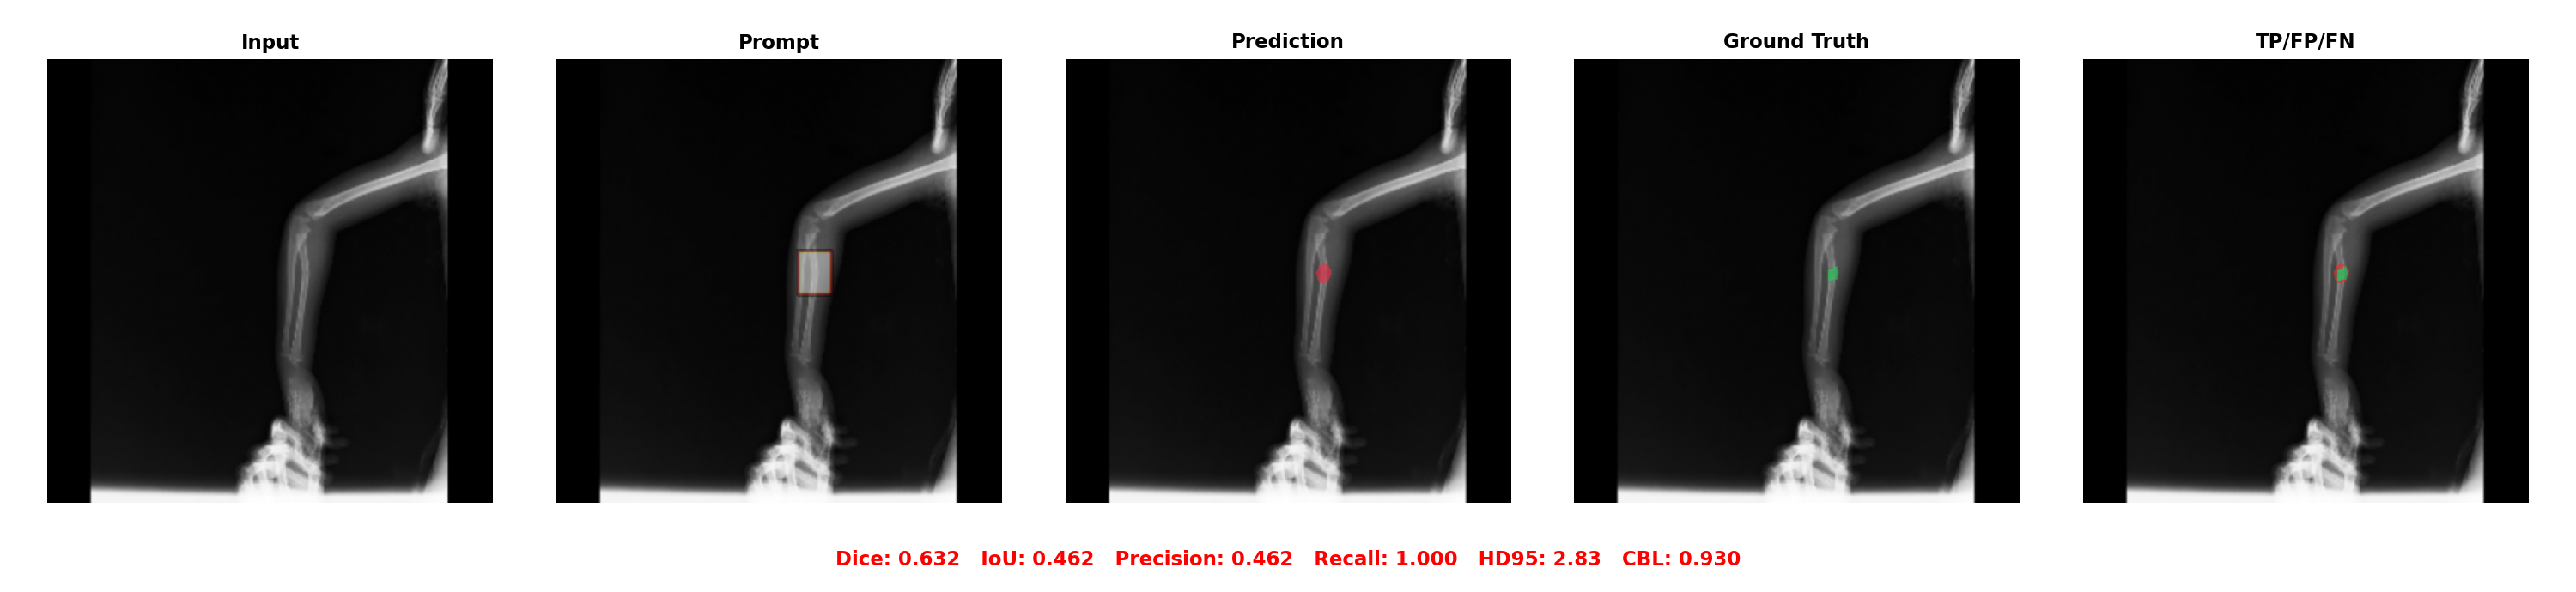

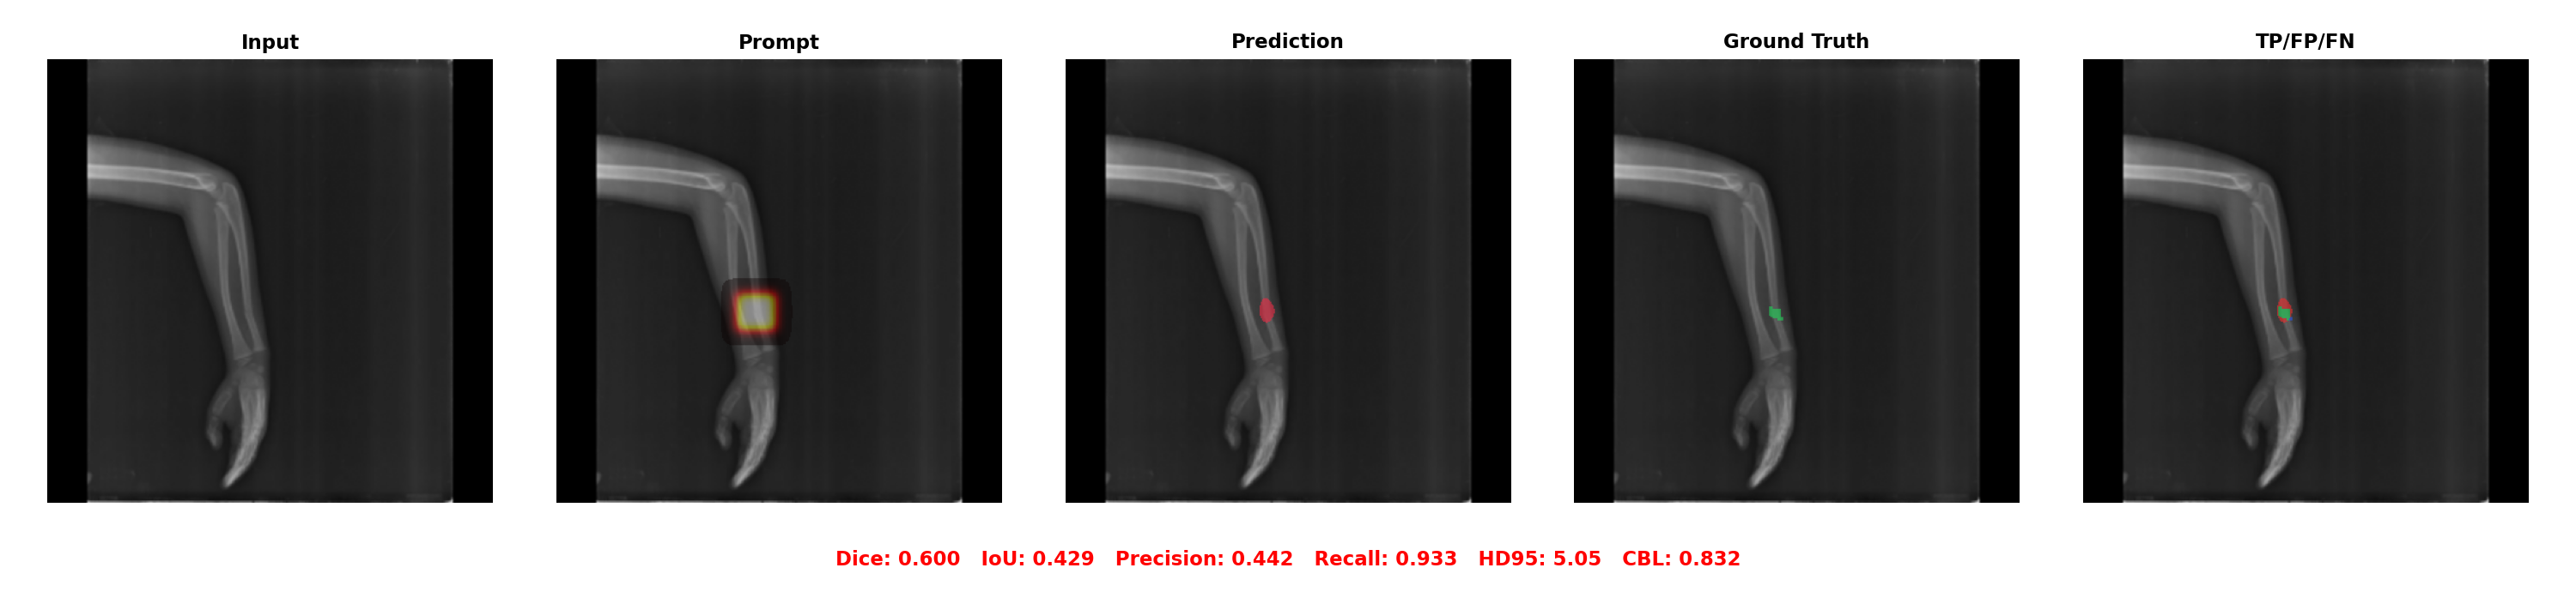

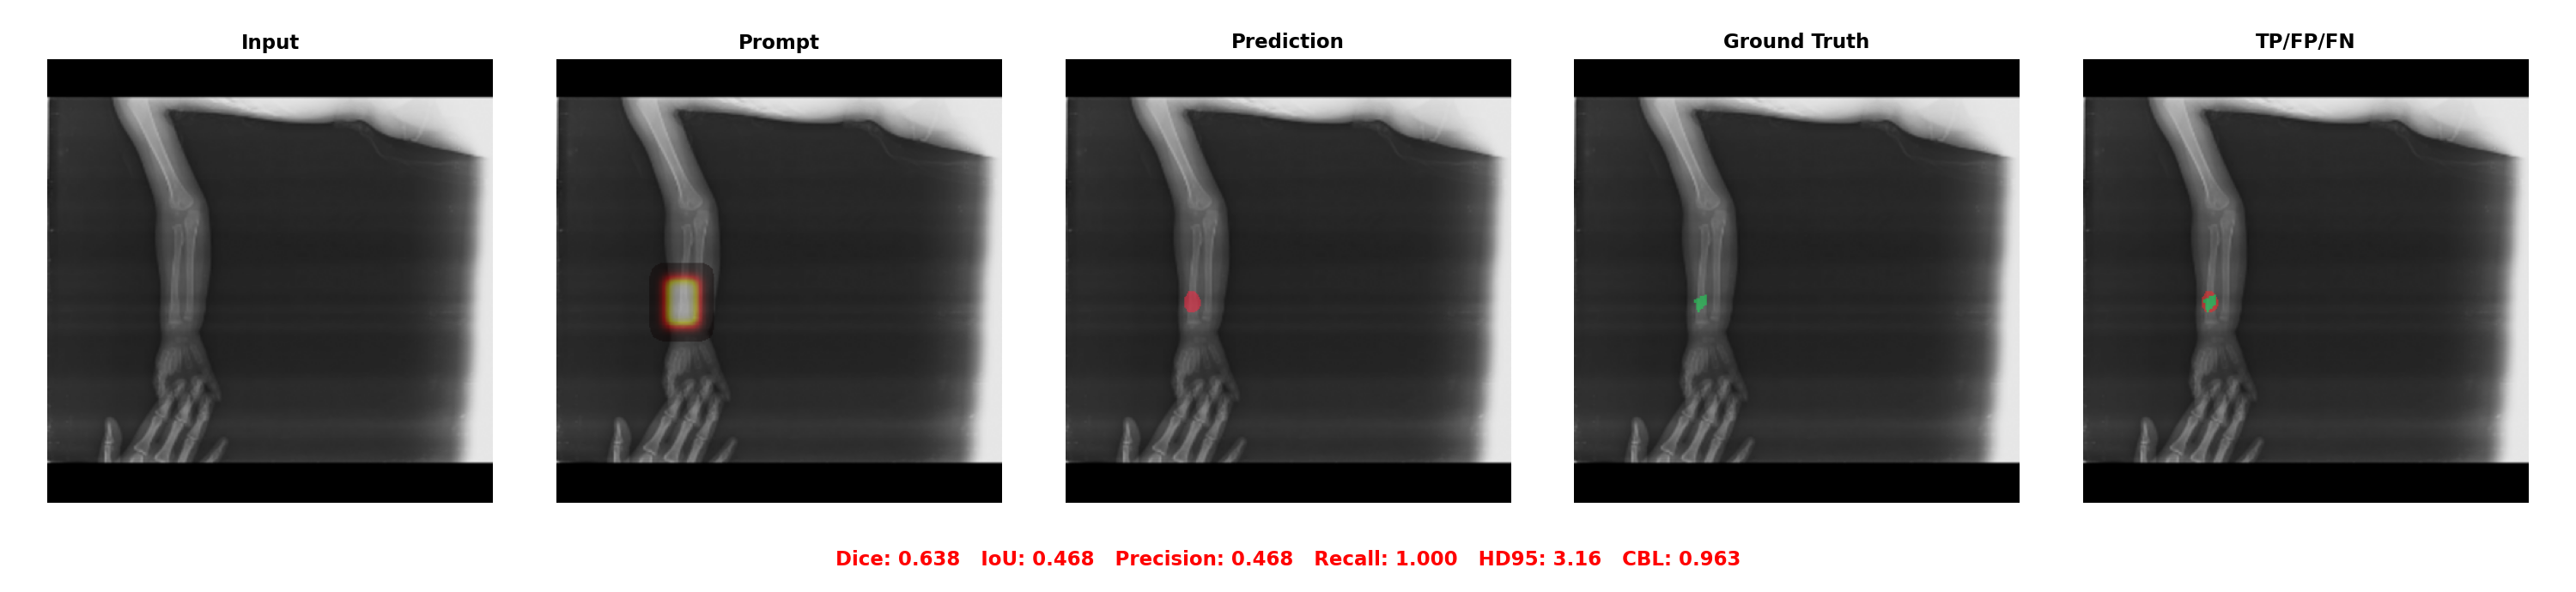

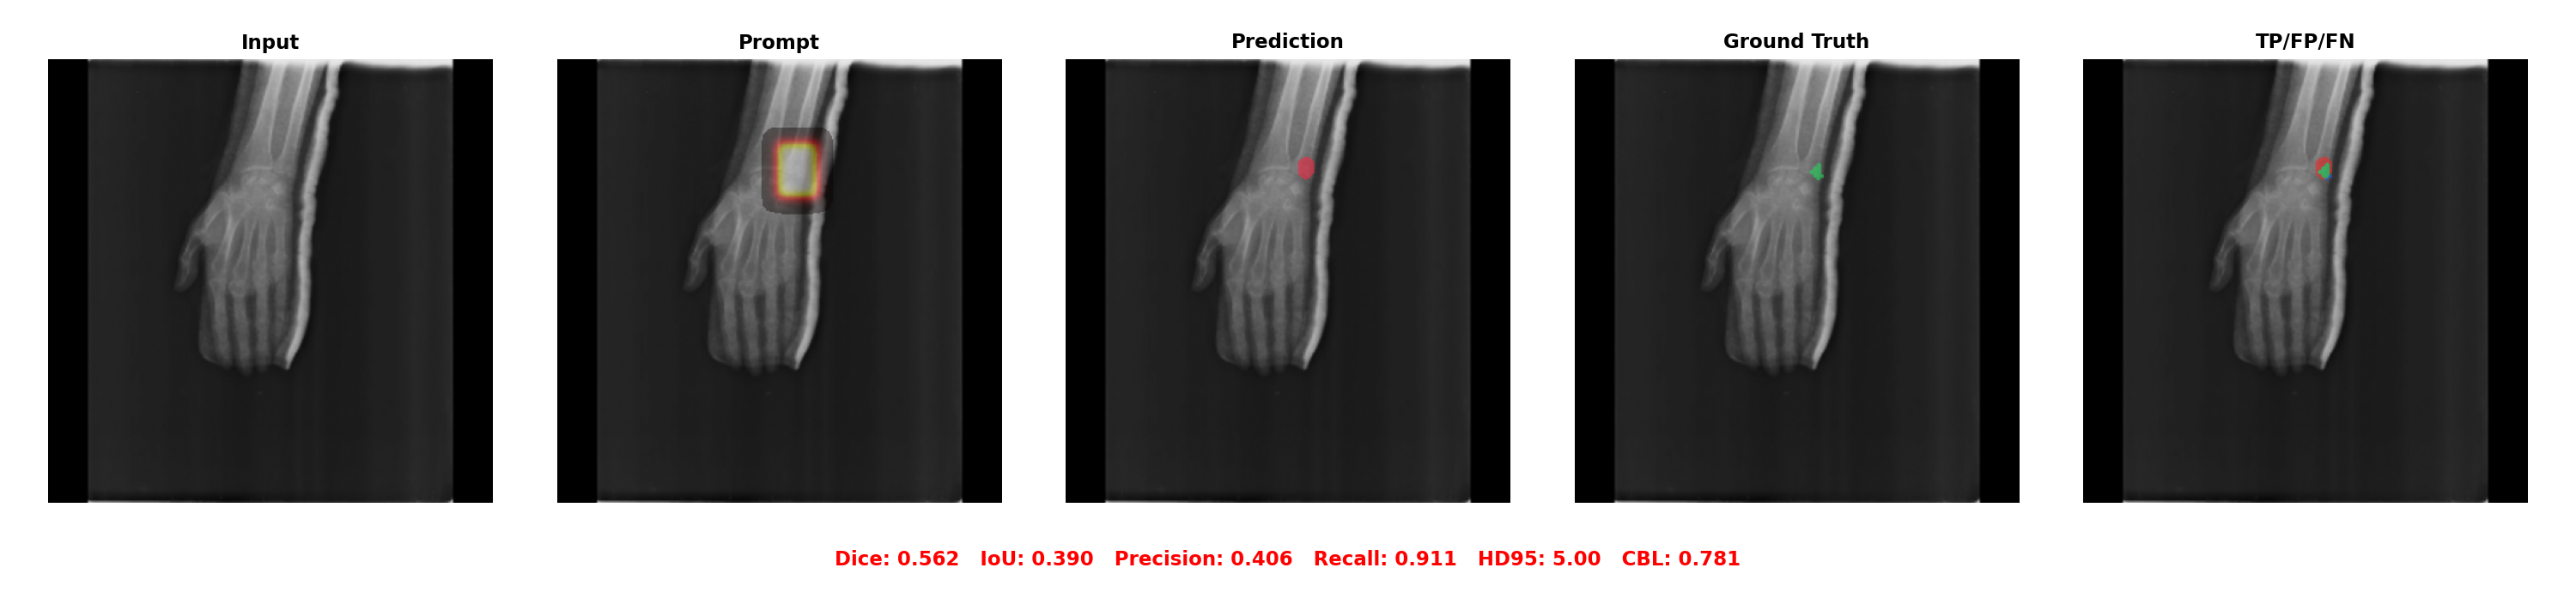

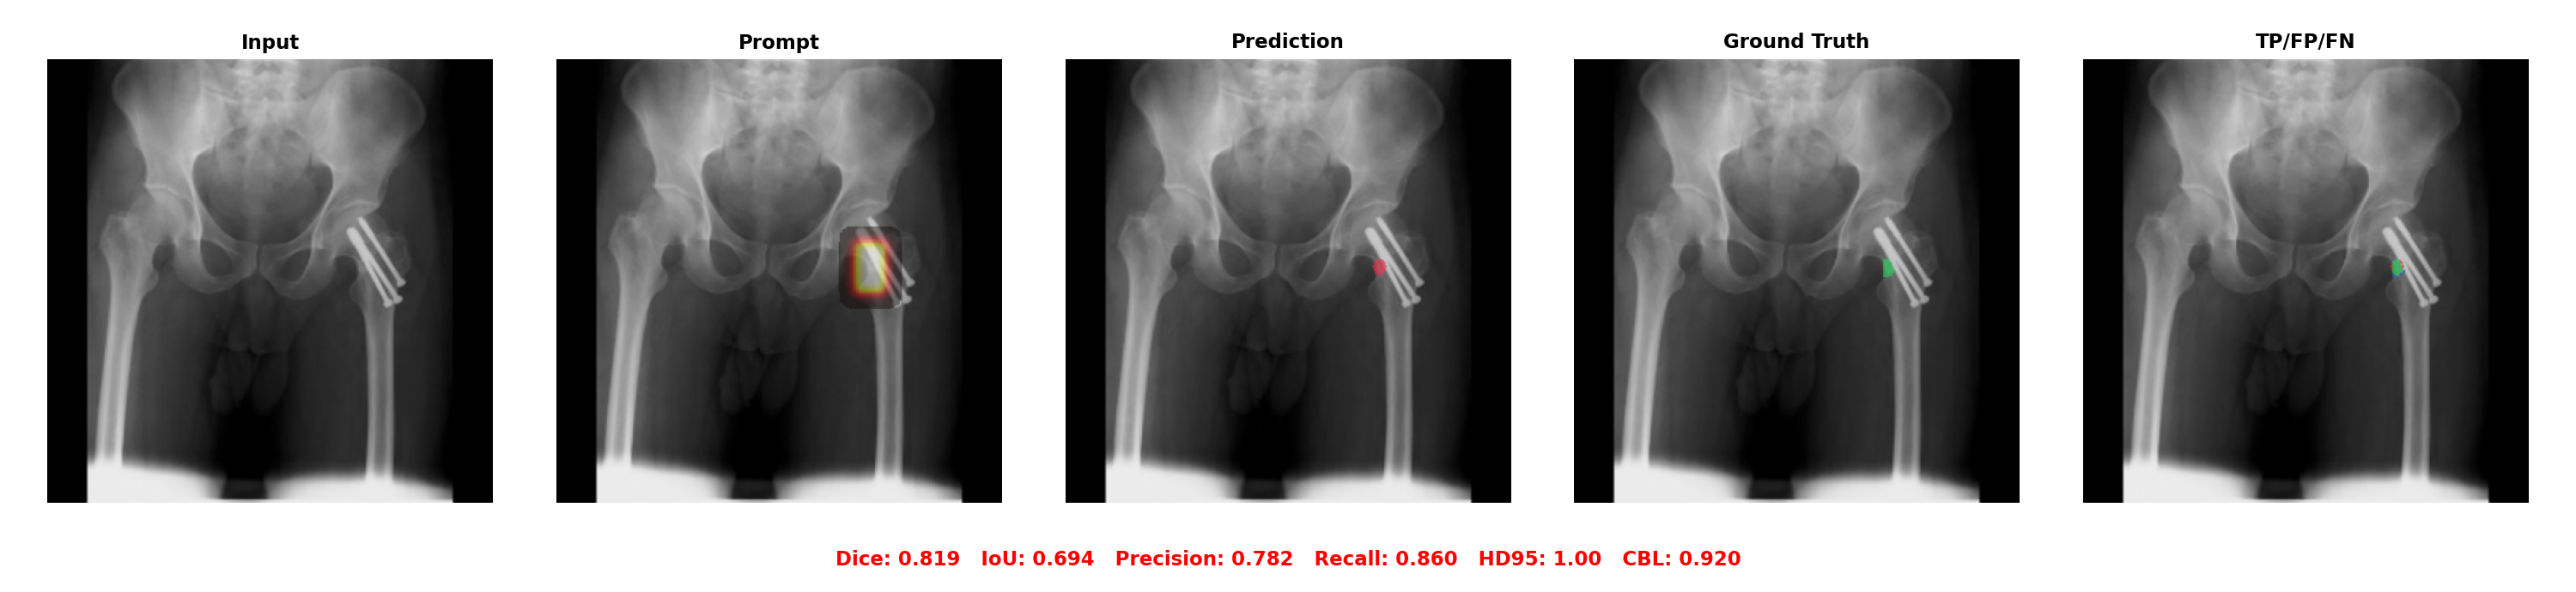

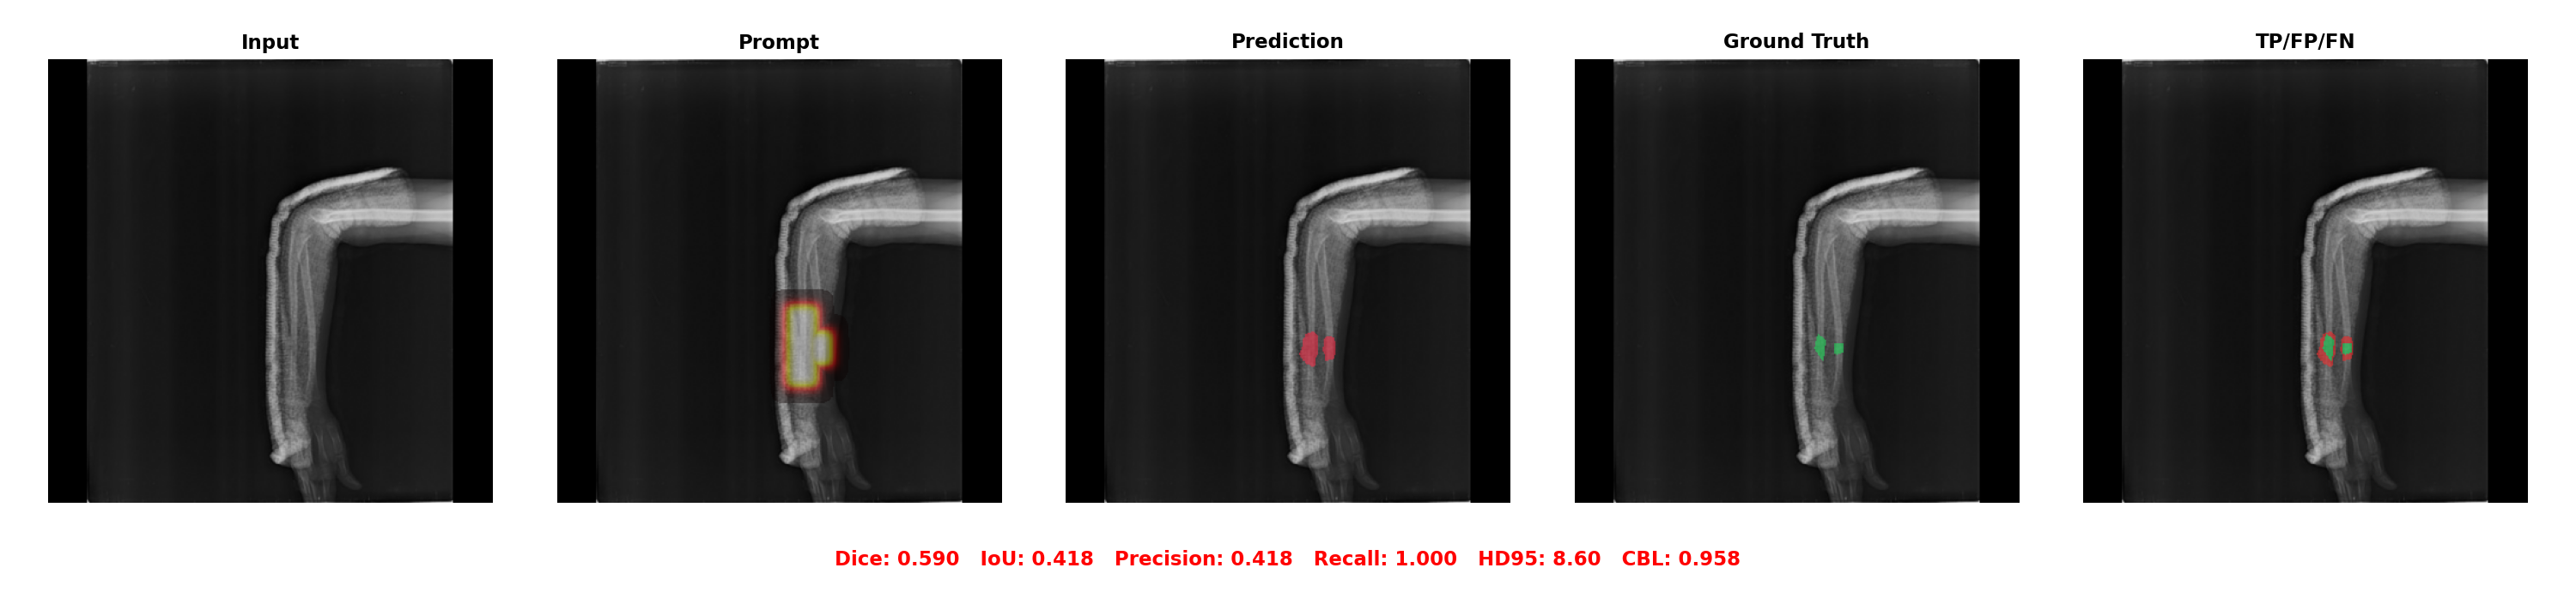

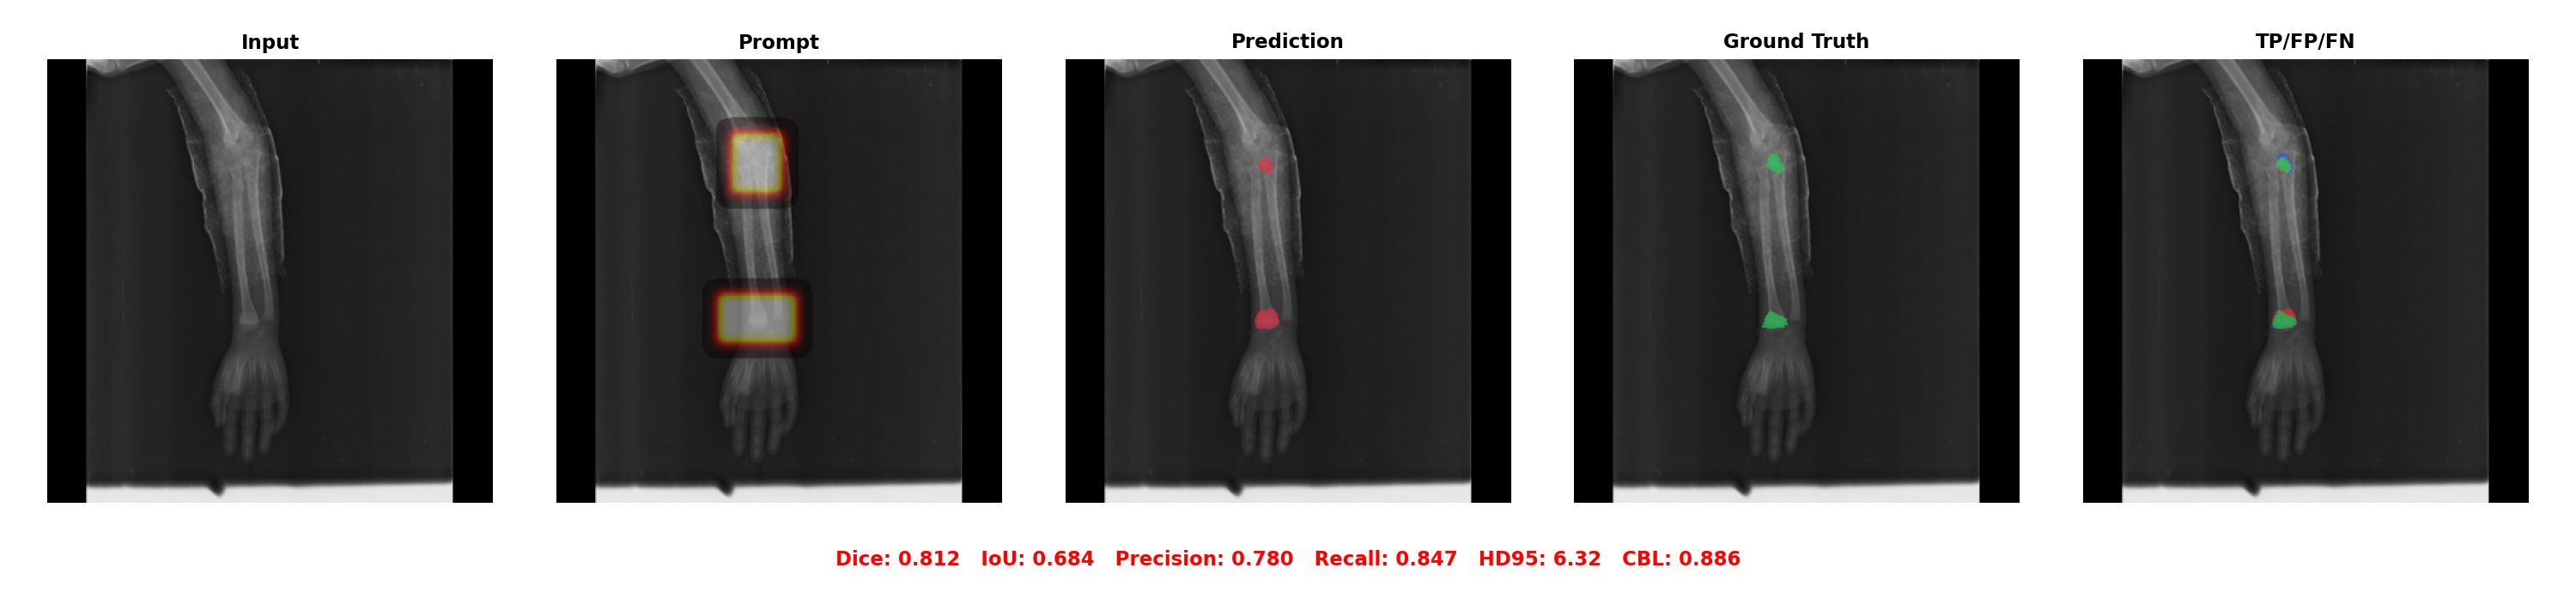

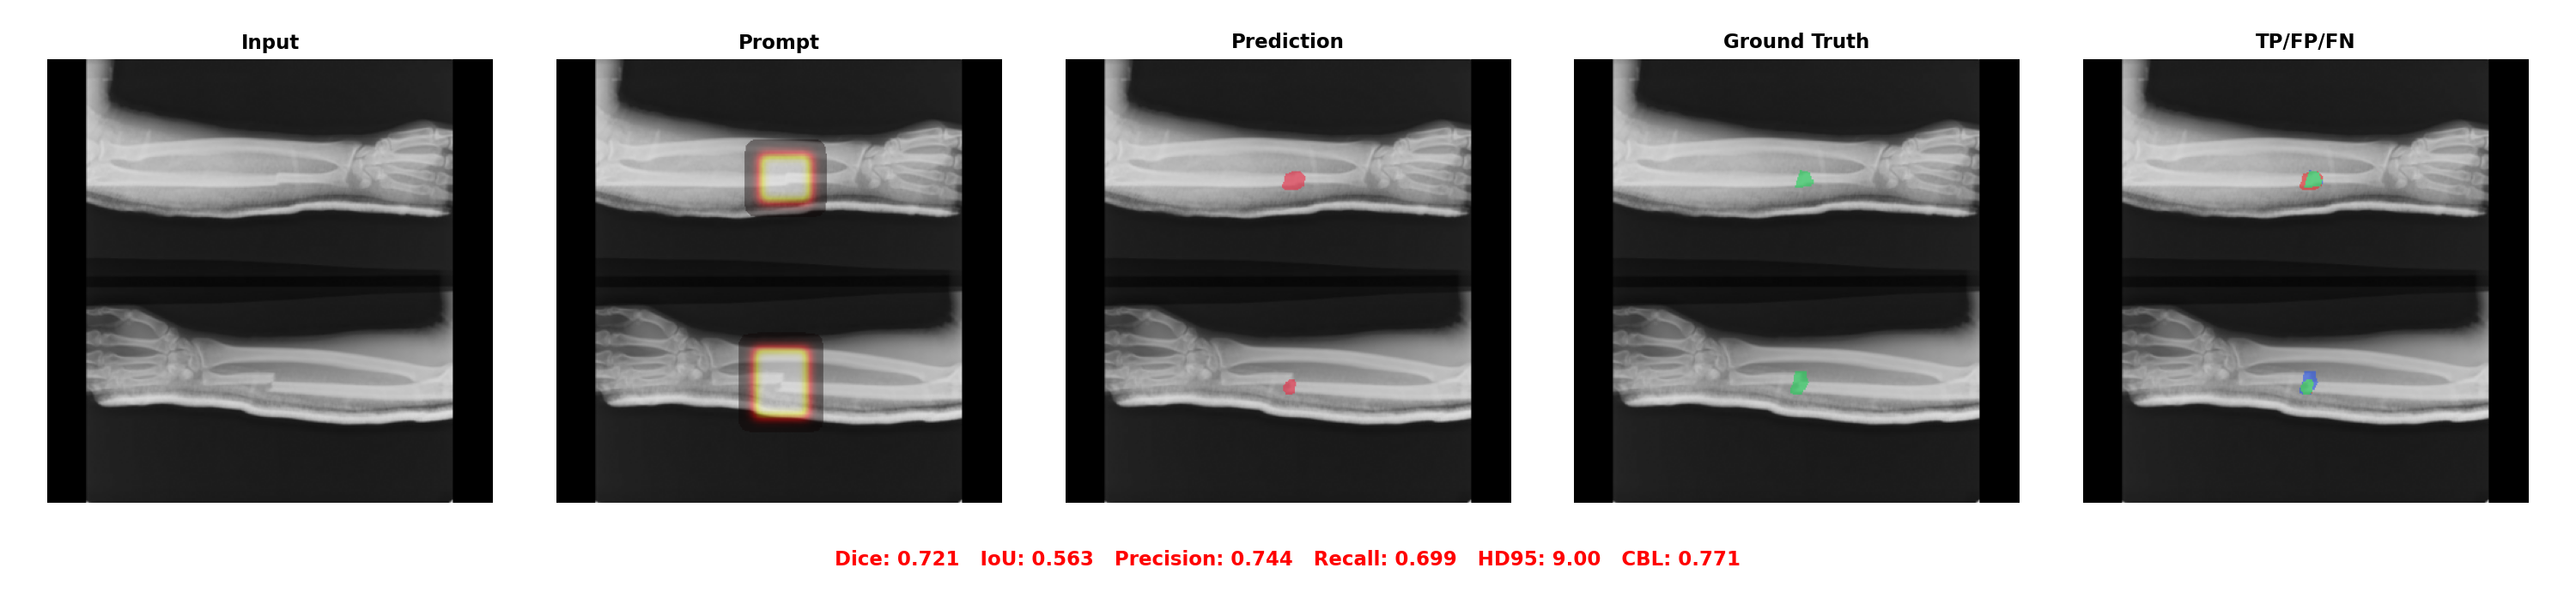

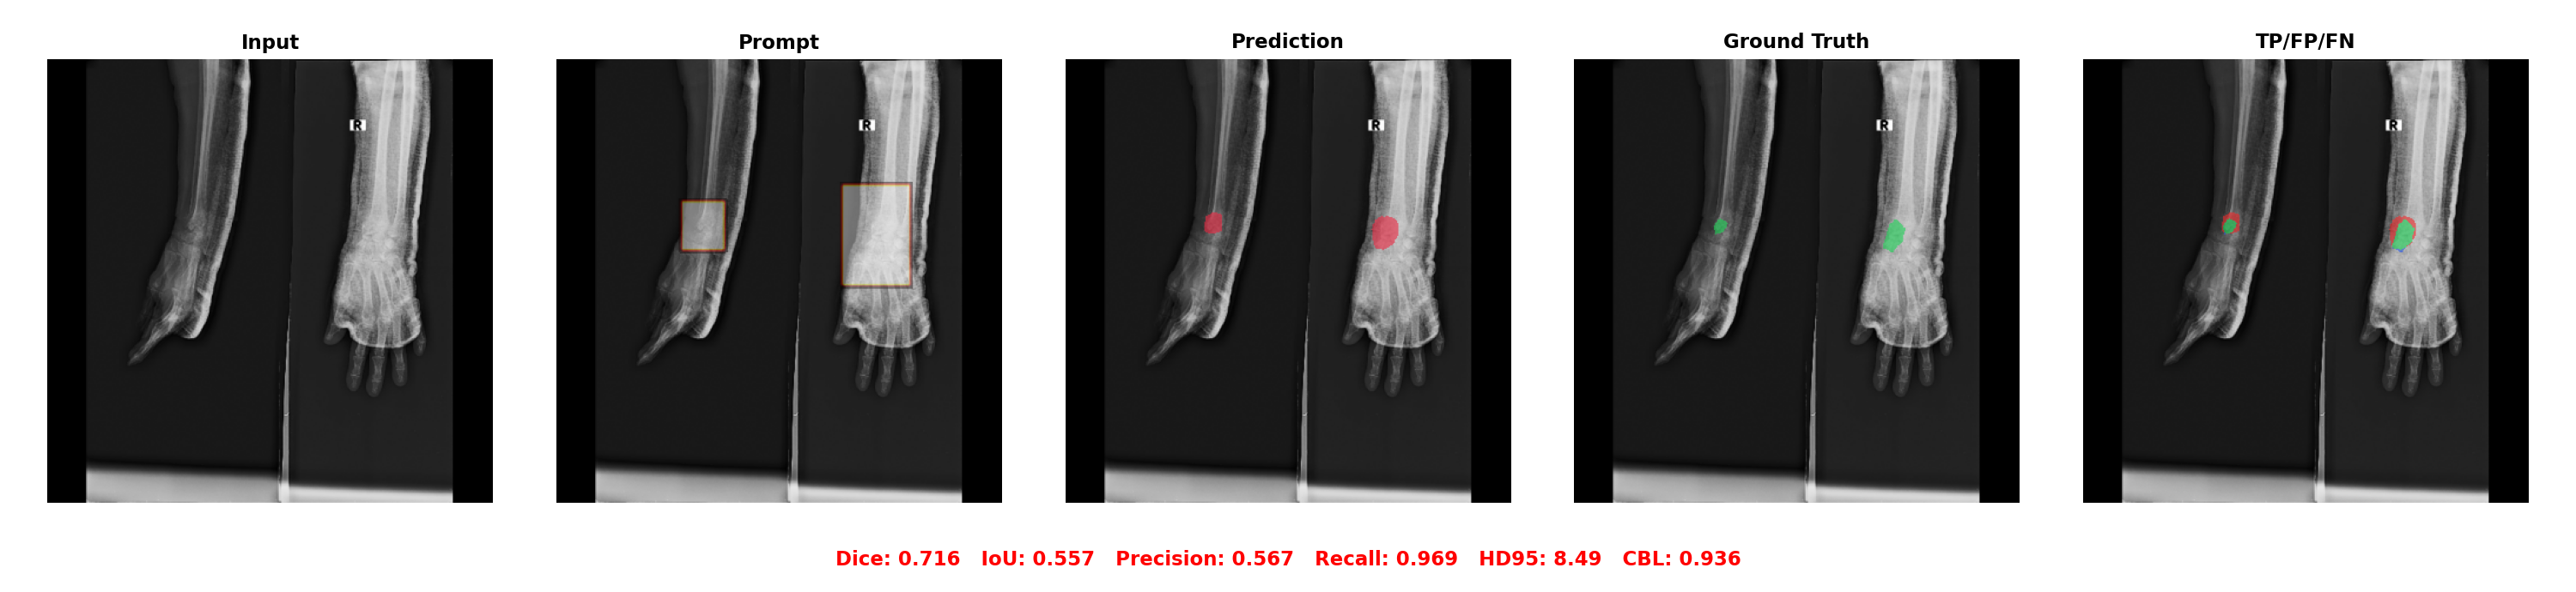

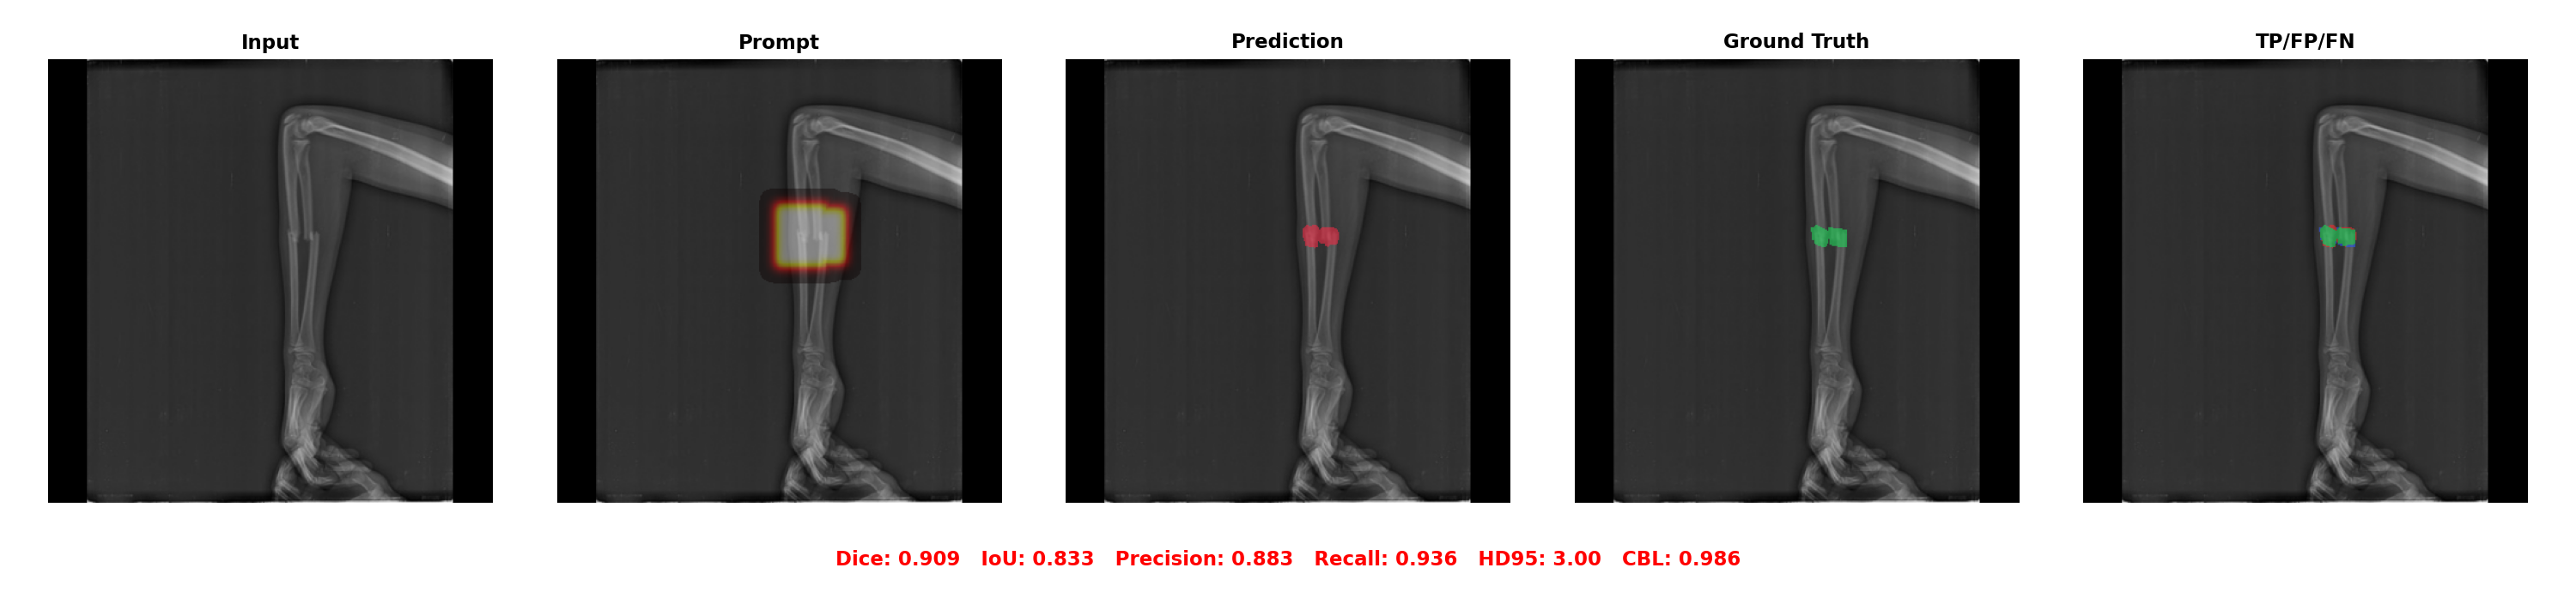

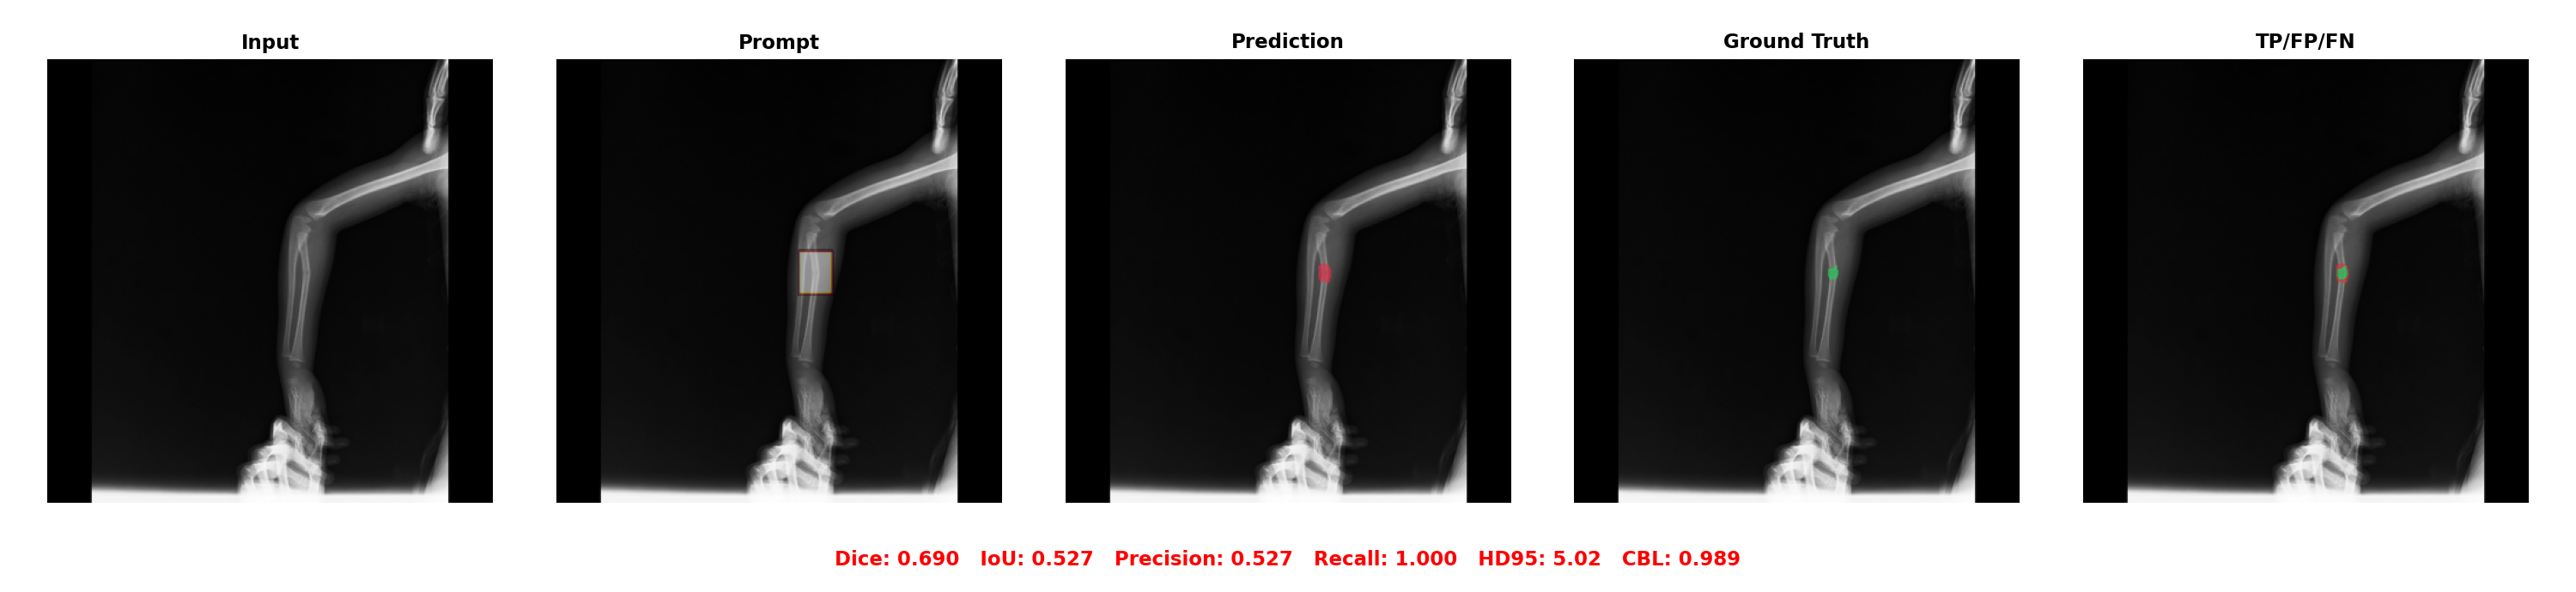

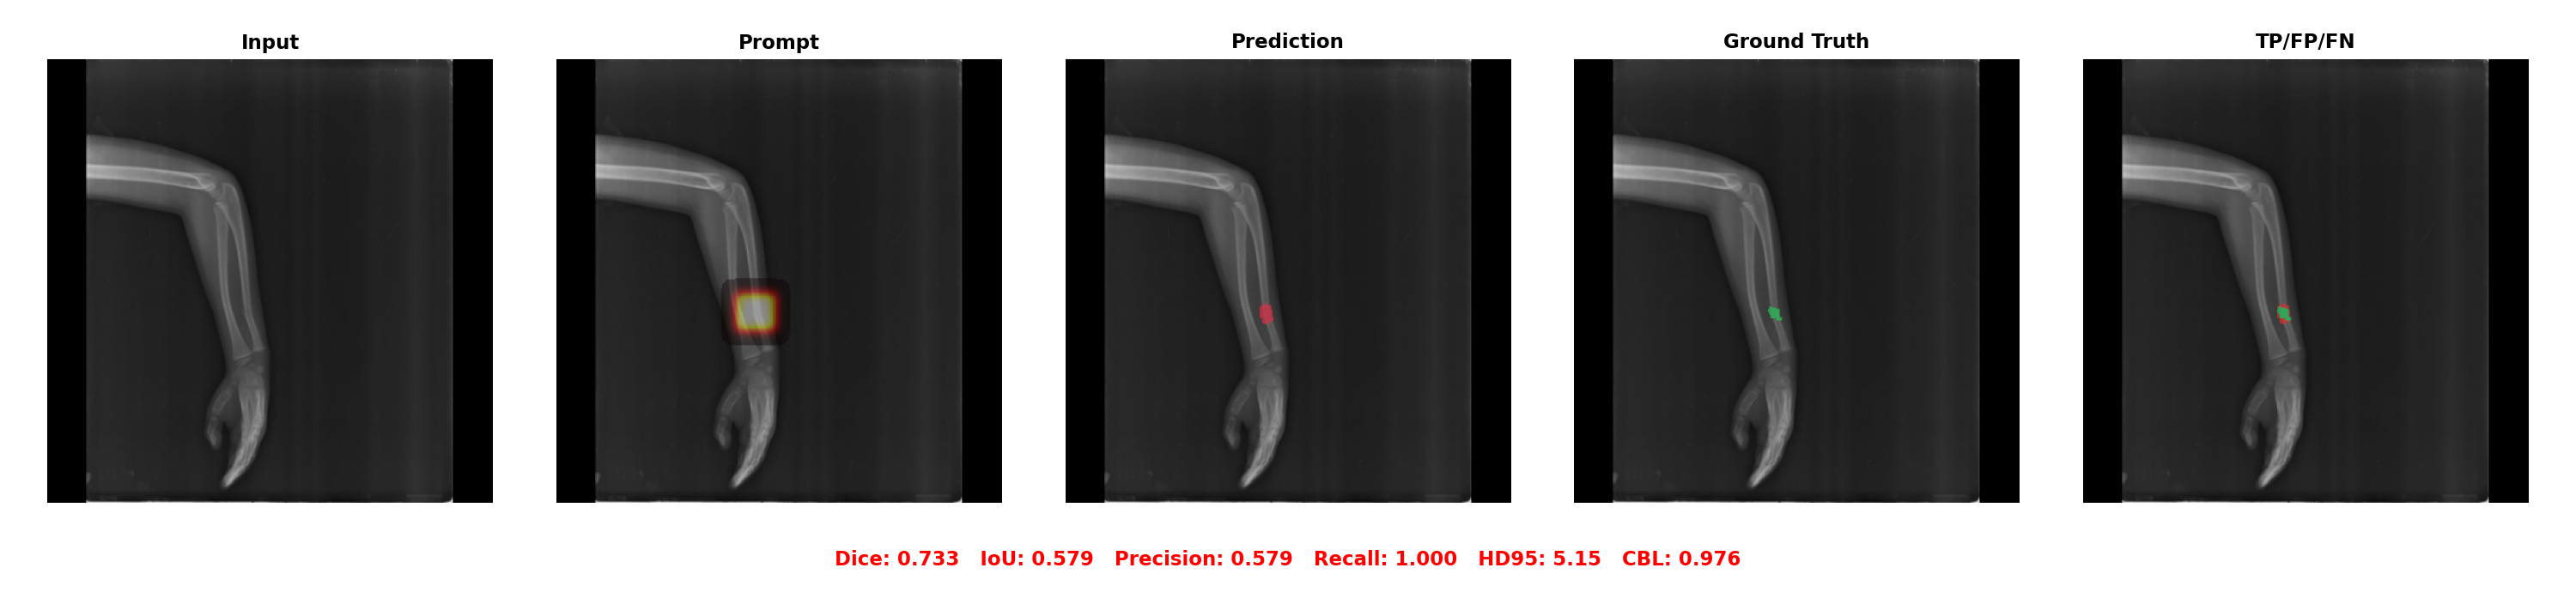

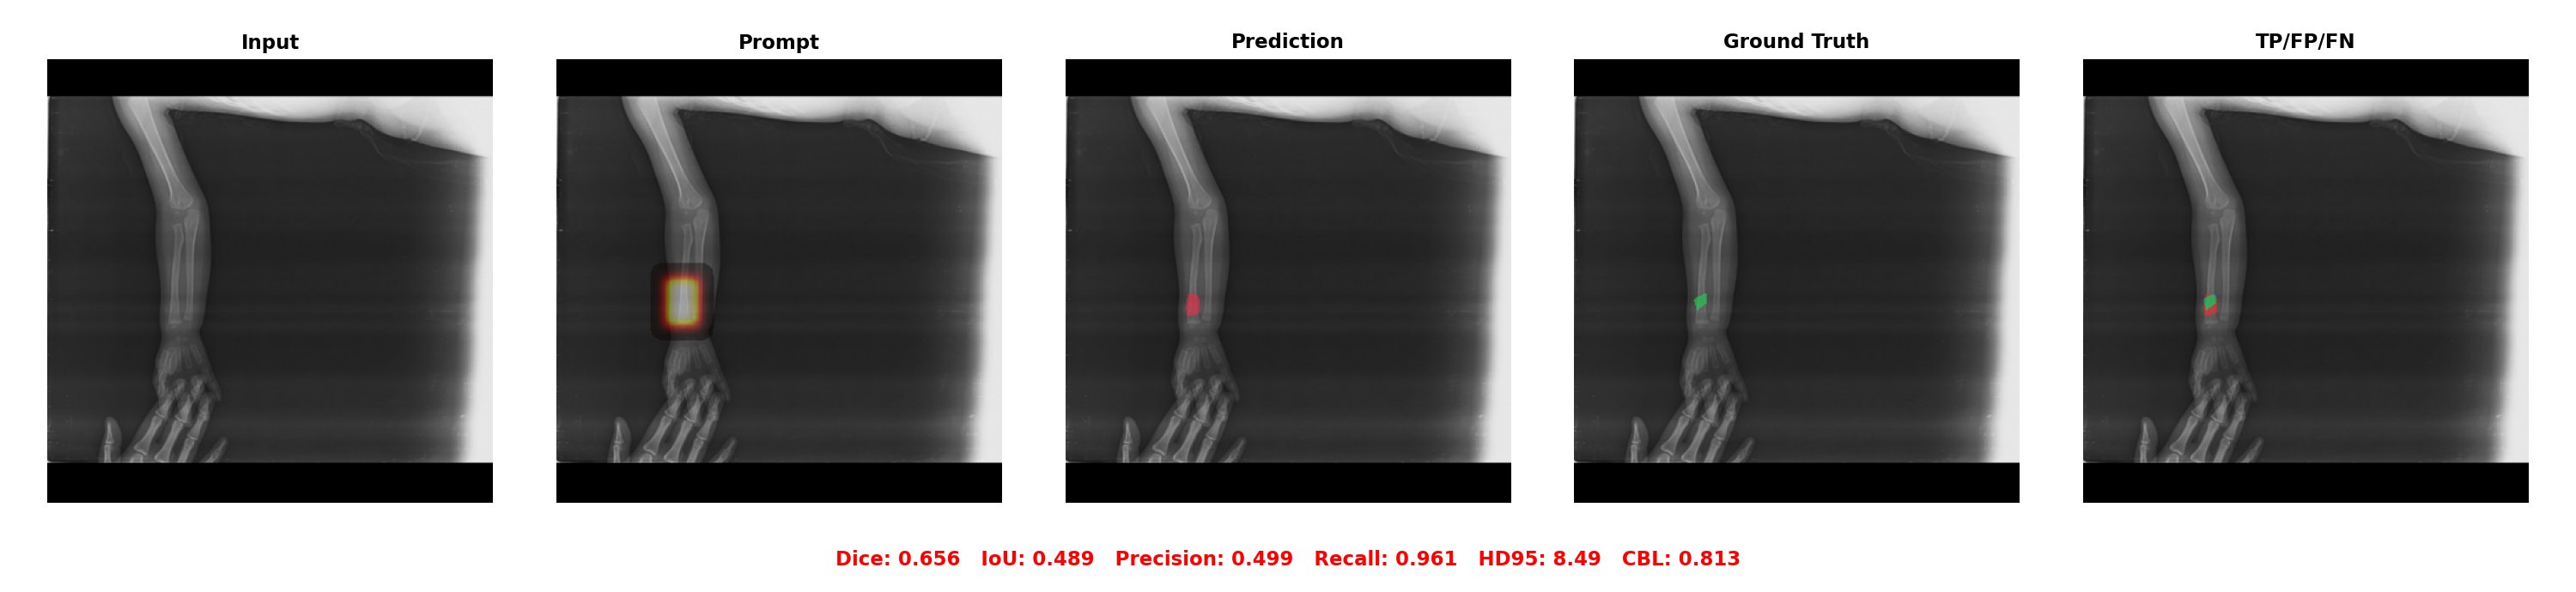

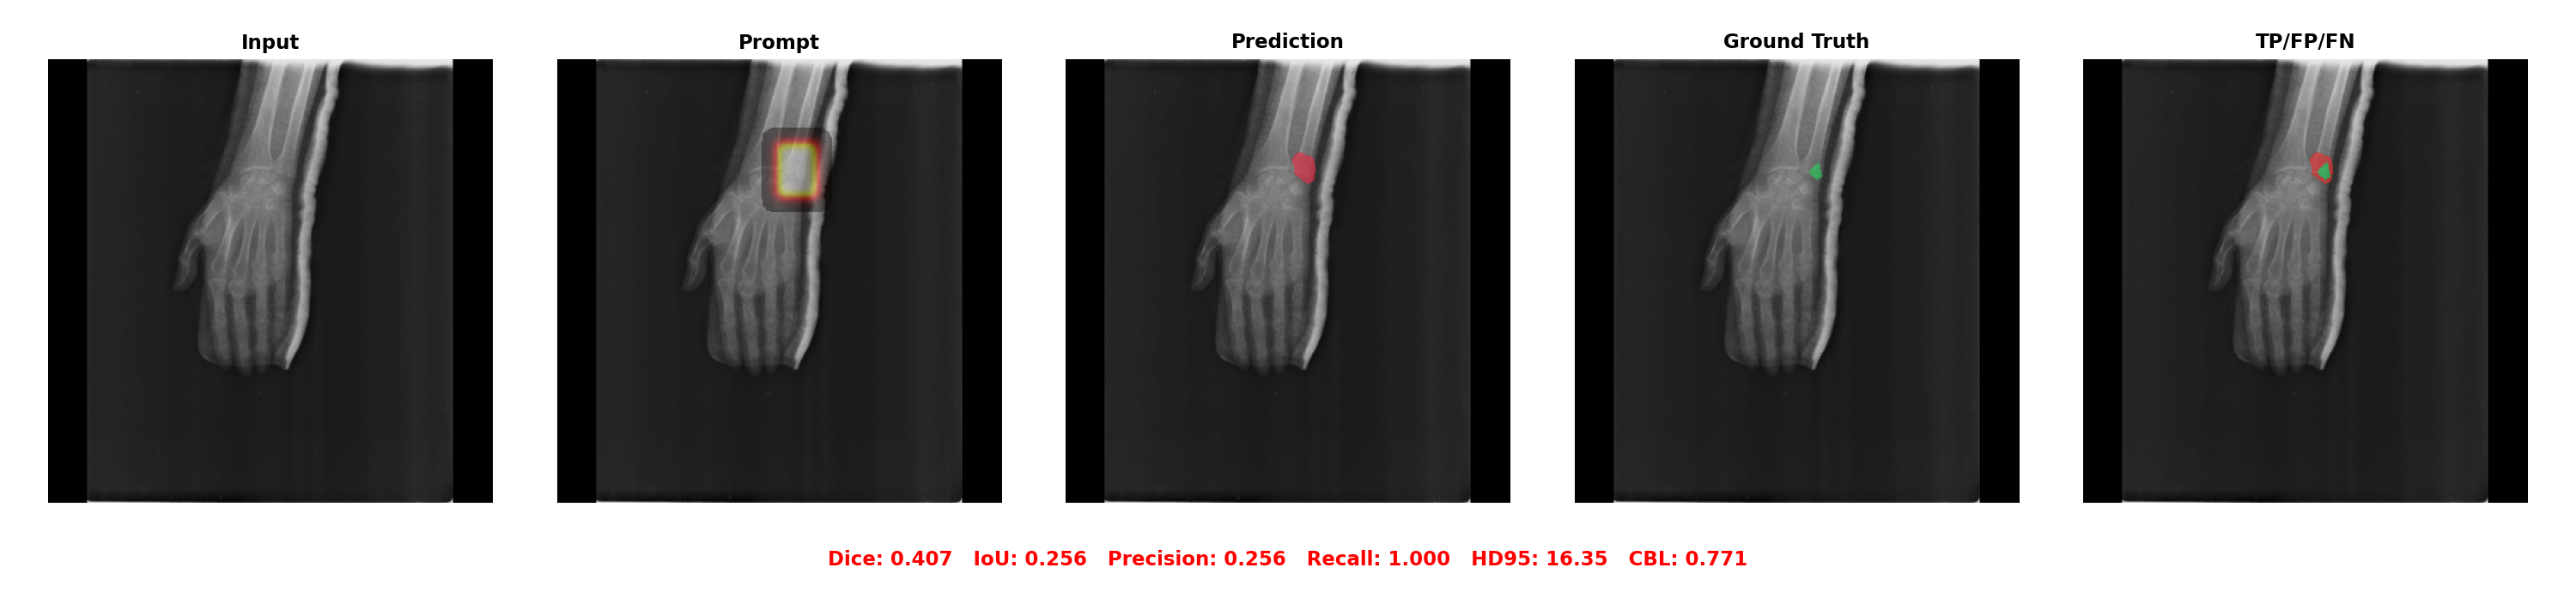

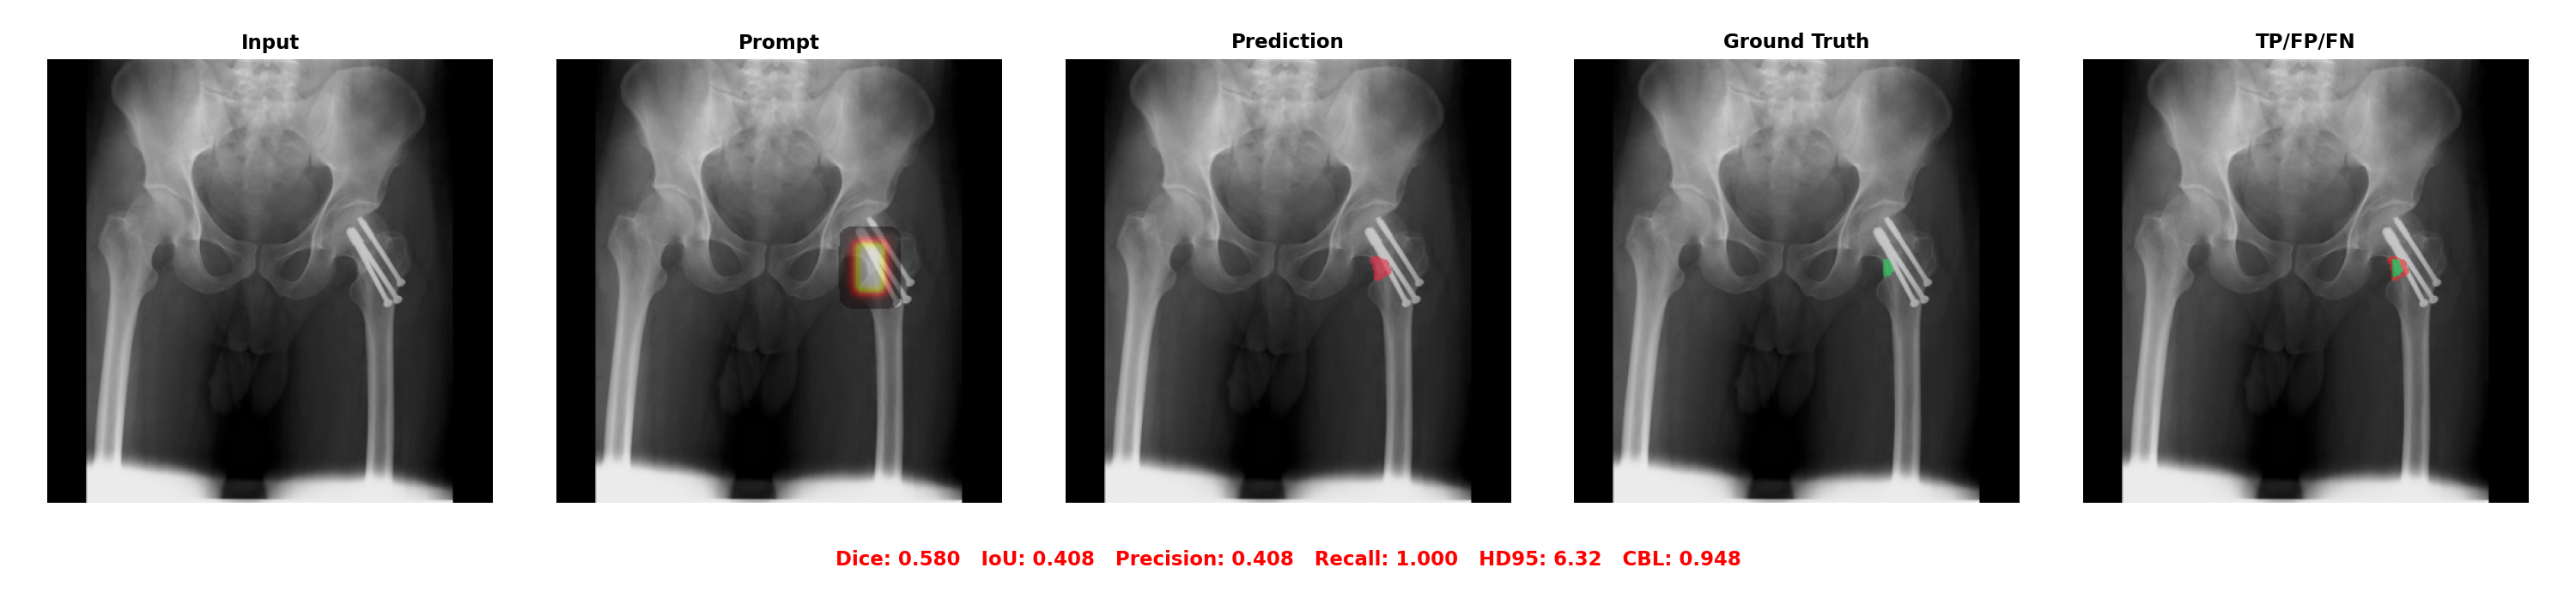

F4: PGA 128 / 256 / 512 small-lesion rows exported.


In [5]:
# ══════════════════════════════════════════════════════
# F4 FIGURE ROWS - PGA-UNet at 128 / 256 / 512 on the small-lesion balanced stems
# One panel per resolution, same stem order -> crop the row you need per figure.
# ══════════════════════════════════════════════════════
import cv2
import matplotlib.pyplot as plt
from qualitative_visualization import export_qualitative_rows

_F4_MODE = "center_zoom"   # doi thanh "center_shift" neu can

def _f4_panel(img_size, prompt_mode=_F4_MODE):
    by_stem = {r["stem"]: r for r in all_records[(img_size, prompt_mode)] if "prob" in r}
    recs = [by_stem[s] for s in VIZ_STEMS if s in by_stem]
    if not recs:
        print(f"  [F4] no array records at {img_size} ({prompt_mode})"); return
    S = 512
    viz = []
    fig, axes = plt.subplots(len(recs), 5, figsize=(20, 4 * len(recs)), squeeze=False)
    fig.suptitle(f"PGA-UNet {img_size} | small-lesion balanced stems ({prompt_mode})",
                 fontsize=12, fontweight="bold", y=1.002)
    for j, t in enumerate(["Input", "Prompt", "Prediction", "Ground Truth", "TP/FP/FN"]):
        axes[0, j].set_title(t, fontsize=10, fontweight="bold")
    for row, r in enumerate(recs):
        img = cv2.resize(np.asarray(r["img"], np.float32), (S, S))
        gray = np.clip(img * 0.5 + 0.5 if img.min() < -0.01 else img, 0, 1)
        hm = cv2.resize(np.asarray(r["prompt"], np.float32), (S, S))
        gt = cv2.resize(np.asarray(r["gt"], np.float32), (S, S), interpolation=cv2.INTER_NEAREST)
        prob = cv2.resize(np.asarray(r["prob"], np.float32), (S, S))
        for k in range(5):
            axes[row, k].imshow(gray, cmap="gray", vmin=0, vmax=1); axes[row, k].axis("off")
        axes[row, 1].imshow(np.where(hm > 1e-4, hm, np.nan), cmap="hot", alpha=0.40, vmin=0, vmax=1)
        m = r["metrics"]
        viz.append(dict(img_name=r["img_name"], gt=gt, prob=prob, prompts=[hm],
                        n_samples=r["n_samples"], dice=m["dice"], iou=m["iou"],
                        precision=m["precision"], recall=m["recall"], hd95=m["hd95"], cbl=m["cbl"]))
    plt.tight_layout()
    export_qualitative_rows(fig, axes, viz)

for _res in RESOLUTIONS:
    _f4_panel(_res)
print("F4: PGA 128 / 256 / 512 small-lesion rows exported.")
